In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import plotly.express as px
import seaborn as sns
import os
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from matplotlib.ticker import FuncFormatter

In [5]:
# List all CSV files in the 'datathon-2026-round-1' directory
csv_dir = 'datathon-2026-round-1'
csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]

# Load each CSV file into a dataframe with variable name as the file name (without .csv)
for file in csv_files:
    var_name = os.path.splitext(file)[0]
    df = pd.read_csv(os.path.join(csv_dir, file))
    globals()[var_name] = df

C:\Users\ASUS\AppData\Local\Temp\ipykernel_41552\2926216130.py:8: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(csv_dir, file))


## Phần 1 - Trả lời câu hỏi

In [6]:
#Q1 
# orders = orders[orders['order_status'] == '']
multi_order = orders['customer_id'].value_counts()
multi_order = multi_order[multi_order > 1].index

orders_multi = orders[orders['customer_id'].isin(multi_order)].copy()

orders_multi['order_date'] = pd.to_datetime(orders_multi['order_date'])

orders_multi = orders_multi.sort_values(['customer_id', 'order_date'])

orders_multi['inter_order_gap'] = orders_multi.groupby('customer_id')['order_date'].diff().dt.days

median_gap = orders_multi['inter_order_gap'].median()
print(f"{median_gap:.0f}")

# Answer: 144

144


In [7]:
#Q2
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']

segment_margin = products.groupby('segment')['gross_margin'].mean().sort_values(ascending=False)

top_segment = segment_margin.idxmax()
top_margin = segment_margin.max()
print(f"Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: {top_segment} ({top_margin:.2%})")
print(segment_margin)
# Answer: Standard
# print(80*'-')
# category_margin = products.groupby('category')['gross_margin'].mean().sort_values(ascending=False)

# top_segment = category_margin.idxmax()
# top_margin = category_margin.max()
# print(f"Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: {top_segment} ({top_margin:.2%})")
# print(category_margin)

Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất: Standard (31.34%)
segment
Standard       0.313442
Premium        0.285377
All-weather    0.284176
Activewear     0.265600
Performance    0.263650
Balanced       0.258038
Trendy         0.240758
Everyday       0.236343
Name: gross_margin, dtype: float64


In [8]:
#Q3
returns_streetwear = returns.merge(products[['product_id', 'category']], on='product_id')

returns_streetwear = returns_streetwear[returns_streetwear['category'] == 'Streetwear']
most_common_reason = returns_streetwear['return_reason'].value_counts().idxmax()
print("Lý do trả hàng nhiều nhất cho Streetwear:", most_common_reason)
print(returns_streetwear['return_reason'].value_counts())
# Answer: wrong_size

Lý do trả hàng nhiều nhất cho Streetwear: wrong_size
return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159
Name: count, dtype: int64


In [9]:
#Q4
avg_bounce_by_source = web_traffic.groupby('traffic_source')['bounce_rate'].mean().sort_values()
lowest_bounce_source = avg_bounce_by_source.idxmin()
lowest_bounce_value = avg_bounce_by_source.min()
print(f"Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất: {lowest_bounce_source} ({lowest_bounce_value:.5f})")
avg_bounce_by_source
#Answer: email_campaign

Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất: email_campaign (0.00446)


traffic_source
email_campaign    0.004458
social_media      0.004476
paid_search       0.004478
referral          0.004499
organic_search    0.004504
direct            0.004511
Name: bounce_rate, dtype: float64

In [10]:
#Q5
promo_applied_pct = order_items['promo_id'].notnull().mean() * 100
print(f"Tỷ lệ dòng áp dụng khuyến mãi: {promo_applied_pct:.2f}%")
#Answer: 39%

Tỷ lệ dòng áp dụng khuyến mãi: 38.66%


In [11]:
#Q6
valid_customers = customers[customers['age_group'].notnull()]

orders_per_customer = orders['customer_id'].value_counts()

valid_customers = valid_customers.copy()
valid_customers['order_count'] = valid_customers['customer_id'].map(orders_per_customer).fillna(0)

avg_orders_by_age = valid_customers.groupby('age_group')['order_count'].mean().sort_values(ascending=False)

top_age_group = avg_orders_by_age.idxmax()
top_avg_orders = avg_orders_by_age.max()
print(f"Nhóm tuổi có số đơn hàng trung bình trên mỗi khách hàng cao nhất: {top_age_group} ({top_avg_orders:.2f})")
avg_orders_by_age

# Answer: 55+

Nhóm tuổi có số đơn hàng trung bình trên mỗi khách hàng cao nhất: 55+ (5.41)


age_group
55+      5.406851
45-54    5.357241
35-44    5.337343
25-34    5.245226
18-24    5.226656
Name: order_count, dtype: float64

In [12]:
#Q7
sales_geo = order_items[["order_id", "unit_price", "quantity"]].copy()
sales_geo["sales"] = sales_geo["unit_price"] * sales_geo["quantity"]

# merge tables
sales_geo = sales_geo.merge(orders[["order_id", "zip"]], on="order_id", how="left")
sales_geo = sales_geo.merge(geography[["zip", "region"]], on="zip", how="left")
# sales_geo['city'] = sales_geo['city'].apply(no_accent_vietnamese).str.lower().str.strip().str.replace('tp. ', '').str.replace(' ', '').str.replace('thành phố ', '').str.replace('-', '').str.replace('city','')

# Calculate total sales by city
city_sales = sales_geo.groupby('region')['sales'].sum().reset_index()
city_sales.sort_values('sales', ascending=False)

# Answer: East

,region,sales
1,East,7.637533e+09
0,Central,4.941908e+09
2,West,3.851035e+09


In [13]:
#Q8
cancel_status = orders[orders['order_status'] == 'cancelled']
payment_method_counts = cancel_status['payment_method'].value_counts()
payment_method_counts

# Answer: credit card

payment_method
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64

In [14]:
# Q9
total_sold_by_size = order_items.merge(products[['product_id', 'size']], on='product_id')
total_sold_by_size = total_sold_by_size.groupby('size')['quantity'].sum()

returns_with_size = returns.merge(products[['product_id', 'size']], on='product_id')
total_returned_by_size = returns_with_size.groupby('size')['return_id'].count()

return_rate_by_size = (total_returned_by_size / total_sold_by_size * 100).fillna(0).sort_values(ascending=False)

for size, rate in return_rate_by_size.items():
    print(f"Size {size}: {rate:.2f}% sản phẩm bị trả hàng")

top_size = return_rate_by_size.idxmax()
print(f"Size có tỷ lệ trả hàng cao nhất: {top_size}")

# Answer: Size XL

Size S: 1.26% sản phẩm bị trả hàng
Size L: 1.25% sản phẩm bị trả hàng
Size M: 1.24% sản phẩm bị trả hàng
Size XL: 1.23% sản phẩm bị trả hàng
Size có tỷ lệ trả hàng cao nhất: S


In [15]:
# Q10
payments_installments = payments[payments['installments'] > 0]
avg_payment_by_plan = payments_installments.groupby('installments')['payment_value'].mean().sort_values(ascending=False)

top_plan = avg_payment_by_plan.idxmax()
top_value = avg_payment_by_plan.max()
print(f"Kế hoạch trả góp có giá trị thanh toán trung bình trên mỗi đơn hàng cao nhất: {top_plan} kỳ ({top_value:,.2f})")
avg_payment_by_plan
# Answer: 6

Kế hoạch trả góp có giá trị thanh toán trung bình trên mỗi đơn hàng cao nhất: 6 kỳ (24,446.65)


installments
6     24446.654403
3     24399.635486
12    24245.772694
1     24113.274166
2       708.473729
Name: payment_value, dtype: float64

## Phần 2 - Đưa ra business insight và EDA

In [16]:
age_group_counts = customers['age_group'].value_counts().sort_index()
age_group_weights = age_group_counts / age_group_counts.sum() * 100# Tính trọng số (tỷ lệ %) cho từng nhóm tuổi

age_group_df = pd.DataFrame({
    'age_group': age_group_counts.index,
    'count': age_group_counts.values,
    'weight': age_group_weights.round(2).values
})

fig = px.bar(
    age_group_df,
    x='age_group',
    y='count',
    labels={'age_group': 'Nhóm tuổi', 'count': 'Số lượng khách hàng'},
    title='Phân bổ khách hàng theo nhóm tuổi',
    custom_data=['count', 'weight'],
    color='count',
    color_continuous_scale='Blues'
)
fig.update_traces(
    hovertemplate='Nhóm tuổi: %{x}<br>Số lượng khách: %{customdata[0]}<br>Trọng số: %{customdata[1]}%'
)
fig.update_layout(showlegend=False)
fig.show()

In [17]:
# reviews = reviews[["product_id", "order_id", "review_date", "rating", "review_title"]]                          # (*)
# order_items = order_items[["product_id", "quantity","discount_amount", "unit_price", "promo_id"]]               # quantity, unit_price, 
# products = products[["product_id", "category", "segment", "price", "cogs", "size"]]                             # category, segment, size, price, cogs
# inventory = inventory[["snapshot_date", "product_id", "stock_on_hand", "units_sold", "units_received", "stockout_days", ]]       # stock_on_hand, units_received, units_sold, stockout_days, sell_through_rate
# orders = orders[["order_id", "order_date", "customer_id", "order_status", "payment_method", "order_source"]]    # order_status, payment_method, order_source

<b>Góc 1: Gross Margin theo Category/Segment qua thời gian</b>

- Join <code>order_items</code> + <code>products</code> → tính <code>(unit_price - cogs) / unit_price</code> theo từng segment/category theo tháng

- Diagnostic: segment nào margin co lại, phải chăng do discount quá nhiều?

- Prescriptive: tối ưu discount policy cho từng segment


<b>Góc 2: Return Rate × Rating — vòng lặp chất lượng sản phẩm</b>

- Join <code>returns</code> + <code>reviews</code> + <code>products</code> theo <code>product_id</code>

- Sản phẩm có return rate cao có rating thấp không? Return reason nào gây mất doanh thu nhất?

- Prescriptive: ưu tiên cải thiện size guide (nếu <code>wrong_size</code> chiếm đa số)

 
Góc 3: Inventory health vs actual demand
- `inventory` có `stockout_flag`, `overstock_flag`, `days_of_supply`
- Cross với `order_items` để thấy revenue bị mất do hết hàng (`stockout_days`)
- Prescriptive: reorder policy theo category dựa trên `days_of_supply`

Góc 4: Order cohort & repeat purchase
- `orders` → cohort theo `order_date` month, xem retention
- Diagnostic: tháng nào có spike đơn hàng (TET, Black Friday)?
- Predictive: leading indicator cho revenue tháng tới

Góc 5: Revenue Leakage — Tiền đang chảy đi đâu?
**Câu hỏi kinh doanh:** Doanh thu thực tế bị mất bao nhiêu, do đâu?

**Mạch phân tích:**
- `order_items` → tính tổng `discount_amount` theo tháng → discount chiếm bao nhiêu % revenue gốc?
- Join với `promotions` → promotion nào tốn chi phí discount nhiều nhất nhưng không tăng quantity?
- Join với `returns` → refund_amount theo category → category nào có net revenue thấp nhất sau khi trừ return?
- **Prescriptive:** Cắt giảm promotion nào? Category nào cần cải thiện chất lượng?


Góc 6: Product Quality Loop — Vòng lặp chất lượng
**Câu hỏi kinh doanh:** Sản phẩm nào đang hại brand?

**Mạch phân tích:**
- Join `reviews` + `returns` + `products` theo `product_id`
- Cross `return_reason` với `rating` → sản phẩm rating thấp có return rate cao không?
- Segment nào (`Premium` vs `Standard`) có gap lớn nhất giữa kỳ vọng (price) và thực tế (rating)?
- `wrong_size` vs `defective` vs `changed_mind` → lý do nào controllable?
- **Prescriptive:** Đầu tư vào size guide, QC, hay product description?


Góc 7: Customer Purchase Pattern — Ai mua, mua khi nào?
**Câu hỏi kinh doanh:** Khi nào nên đẩy marketing/promotion?

**Mạch phân tích:**
- `orders` → aggregate theo tháng/quý → seasonality rõ không? (Tết, 11/11, Black Friday)
- `order_items` join `products` → category nào bán chạy theo mùa?
- `orders.order_source` + `orders.device_type` → channel nào convert tốt nhất?
- Cohort analysis: khách mua lần đầu tháng nào có retention cao nhất?
- **Prescriptive:** Lịch promotion tối ưu theo mùa + channel allocation

In [18]:
sales['Date'] = pd.to_datetime(sales['Date'])
sales = sales.sort_values('Date').reset_index(drop=True)
sales['gross_margin_pct'] = np.where(sales['Revenue'] != 0,
                                    (sales['Revenue'] - sales['COGS']) / sales['Revenue'],
                                    np.nan)

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(
    go.Scatter(x=sales['Date'], y=sales['Revenue'], mode='lines+markers',
               name='Revenue', line=dict(color='#1f77b4')),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=sales['Date'], y=sales['COGS'], mode='lines+markers',
               name='COGS', line=dict(color='#ff7f0e')),
    secondary_y=False
)

# Gross margin % on secondary y
fig.add_trace(
    go.Scatter(x=sales['Date'], y=sales['gross_margin_pct'], mode='lines+markers',
               name='Gross Margin %', line=dict(color='#2ca02c'),
               hovertemplate='%{x}<br>Gross Margin: %{y:.2%}'),
    secondary_y=True
)

# aggregate to month (use 'ME' for month end frequency)
sales_monthly = sales.set_index('Date').resample('ME').sum()[['Revenue','COGS']].reset_index()
sales_monthly['gross_margin_pct'] = np.where(
    sales_monthly['Revenue'] != 0,
    (sales_monthly['Revenue'] - sales_monthly['COGS']) / sales_monthly['Revenue'],
    np.nan
)

# replace traces data with monthly series
fig.data[0].x = sales_monthly['Date']
fig.data[0].y = sales_monthly['Revenue']
fig.data[1].x = sales_monthly['Date']
fig.data[1].y = sales_monthly['COGS']
fig.data[2].x = sales_monthly['Date']
fig.data[2].y = sales_monthly['gross_margin_pct']

# improve hover and x-axis display for months
fig.update_traces(selector=dict(name='Revenue'), hovertemplate='%{x|%Y-%m}<br>Revenue: %{y:,.0f}')
fig.update_traces(selector=dict(name='COGS'), hovertemplate='%{x|%Y-%m}<br>COGS: %{y:,.0f}')
fig.update_traces(selector=dict(name='Gross Margin %'), hovertemplate='%{x|%Y-%m}<br>Gross Margin: %{y:.2%}')
fig.update_xaxes(tickformat='%Y-%m', dtick="M3")  # show every 3 months for readability
fig.update_layout(
    title='Daily Revenue, COGS and Gross Margin %',
    xaxis_title='Date',
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)
fig.update_yaxes(title_text='Amount (VND)', secondary_y=False, tickformat=',')
fig.update_yaxes(title_text='Gross Margin (%)', secondary_y=True, tickformat='.0%')

fig.show()

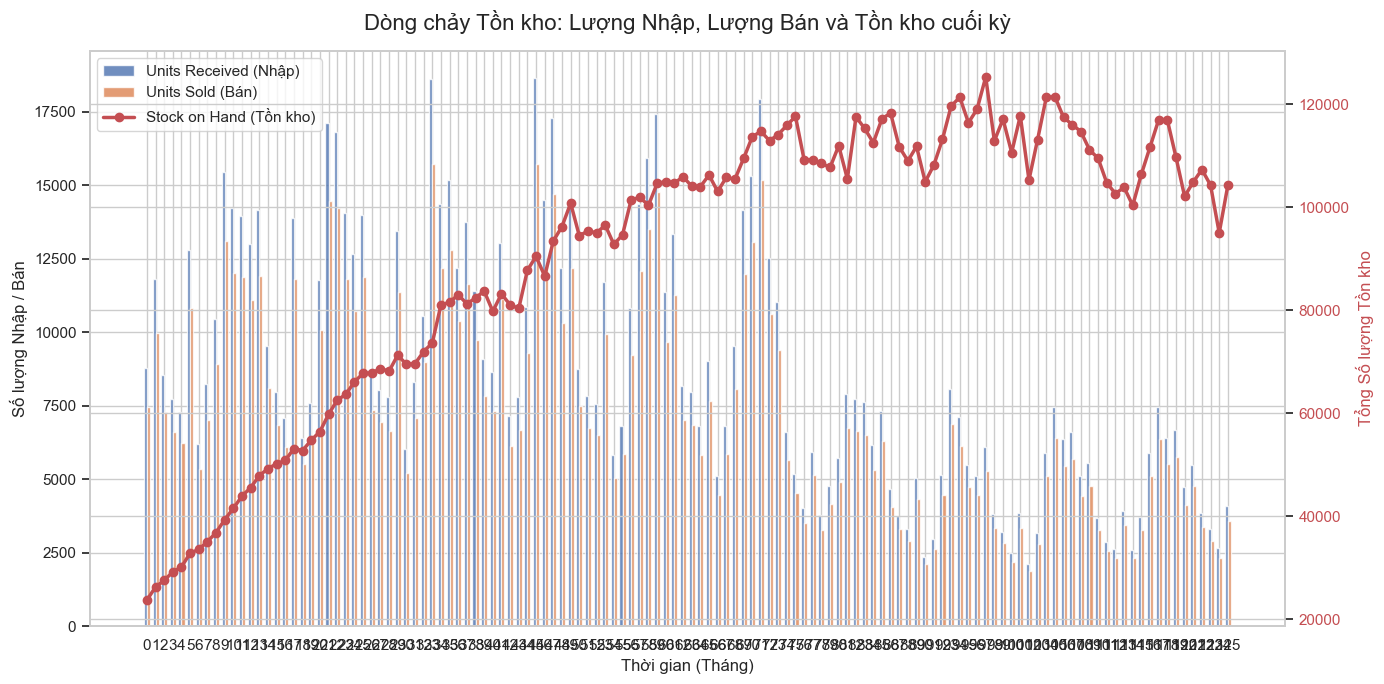

In [20]:
# Thiết lập style chung cho đồ thị đẹp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Tính tổng các chỉ số theo từng tháng
inv_monthly = inventory.groupby('snapshot_date')[['units_received', 'units_sold', 'stock_on_hand']].sum().reset_index()

# Khởi tạo figure
fig, ax1 = plt.subplots(figsize=(14, 7))

# Thiết lập vị trí cho các cột (Bar chart)
x = np.arange(len(inv_monthly['snapshot_date']))
width = 0.35

# Vẽ Bar chart cho Nhập và Bán trên trục Y thứ nhất
ax1.bar(x - width/2, inv_monthly['units_received'], width, label='Units Received (Nhập)', color='#4c72b0', alpha=0.8)
ax1.bar(x + width/2, inv_monthly['units_sold'], width, label='Units Sold (Bán)', color='#dd8452', alpha=0.8)

ax1.set_xlabel('Thời gian (Tháng)', fontsize=12)
ax1.set_ylabel('Số lượng Nhập / Bán', fontsize=12)
ax1.set_xticks(x)

# Khởi tạo trục Y thứ hai (dùng chung trục X) để vẽ Line chart cho Tồn kho
ax2 = ax1.twinx()
ax2.plot(x, inv_monthly['stock_on_hand'], label='Stock on Hand (Tồn kho)', color='#c44e52', marker='o', linewidth=2.5)
ax2.set_ylabel('Tổng Số lượng Tồn kho', fontsize=12, color='#c44e52')
ax2.tick_params(axis='y', labelcolor='#c44e52')

# Gom chú thích (legend) của cả 2 trục lại với nhau
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Dòng chảy Tồn kho: Lượng Nhập, Lượng Bán và Tồn kho cuối kỳ', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

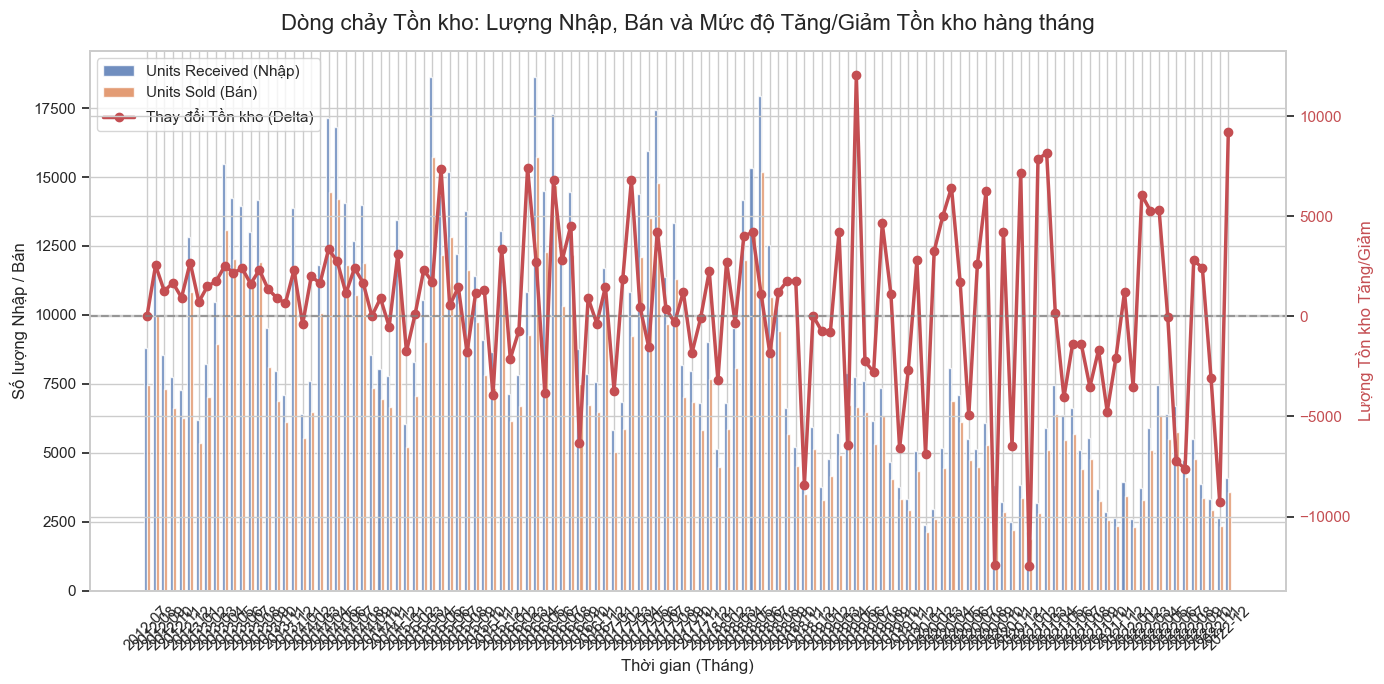

In [23]:
# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Đọc dữ liệu và ép kiểu datetime
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# 2. Nhóm dữ liệu theo tháng
inv_monthly = inventory.groupby('snapshot_date')[['units_received', 'units_sold', 'stock_on_hand']].sum().reset_index()

# TÍNH TOÁN LƯỢNG TỒN KHO TĂNG/GIẢM SO VỚI THÁNG TRƯỚC (Net Change)
# Dùng hàm .diff() để trừ tháng hiện tại cho tháng trước. fillna(0) để xử lý giá trị rỗng ở tháng đầu tiên.
inv_monthly['stock_change'] = inv_monthly['stock_on_hand'].diff().fillna(0)

# 3. Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(14, 7))

x = np.arange(len(inv_monthly['snapshot_date']))
width = 0.35

# Vẽ Bar chart cho Nhập và Bán
ax1.bar(x - width/2, inv_monthly['units_received'], width, label='Units Received (Nhập)', color='#4c72b0', alpha=0.8)
ax1.bar(x + width/2, inv_monthly['units_sold'], width, label='Units Sold (Bán)', color='#dd8452', alpha=0.8)

ax1.set_xlabel('Thời gian (Tháng)', fontsize=12)
ax1.set_ylabel('Số lượng Nhập / Bán', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(inv_monthly['snapshot_date'].dt.strftime('%Y-%m'), rotation=45)

# Khởi tạo trục Y thứ hai để vẽ Line chart cho MỨC THAY ĐỔI TỒN KHO
ax2 = ax1.twinx()
ax2.plot(x, inv_monthly['stock_change'], label='Thay đổi Tồn kho (Delta)', color='#c44e52', marker='o', linewidth=2.5)
ax2.set_ylabel('Lượng Tồn kho Tăng/Giảm', fontsize=12, color='#c44e52')
ax2.tick_params(axis='y', labelcolor='#c44e52')

# Vẽ đường cơ sở y=0 để dễ nhìn thấy tháng nào tồn kho tăng (trên 0) hay giảm (dưới 0)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# Gom chú thích
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Dòng chảy Tồn kho: Lượng Nhập, Bán và Mức độ Tăng/Giảm Tồn kho hàng tháng', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

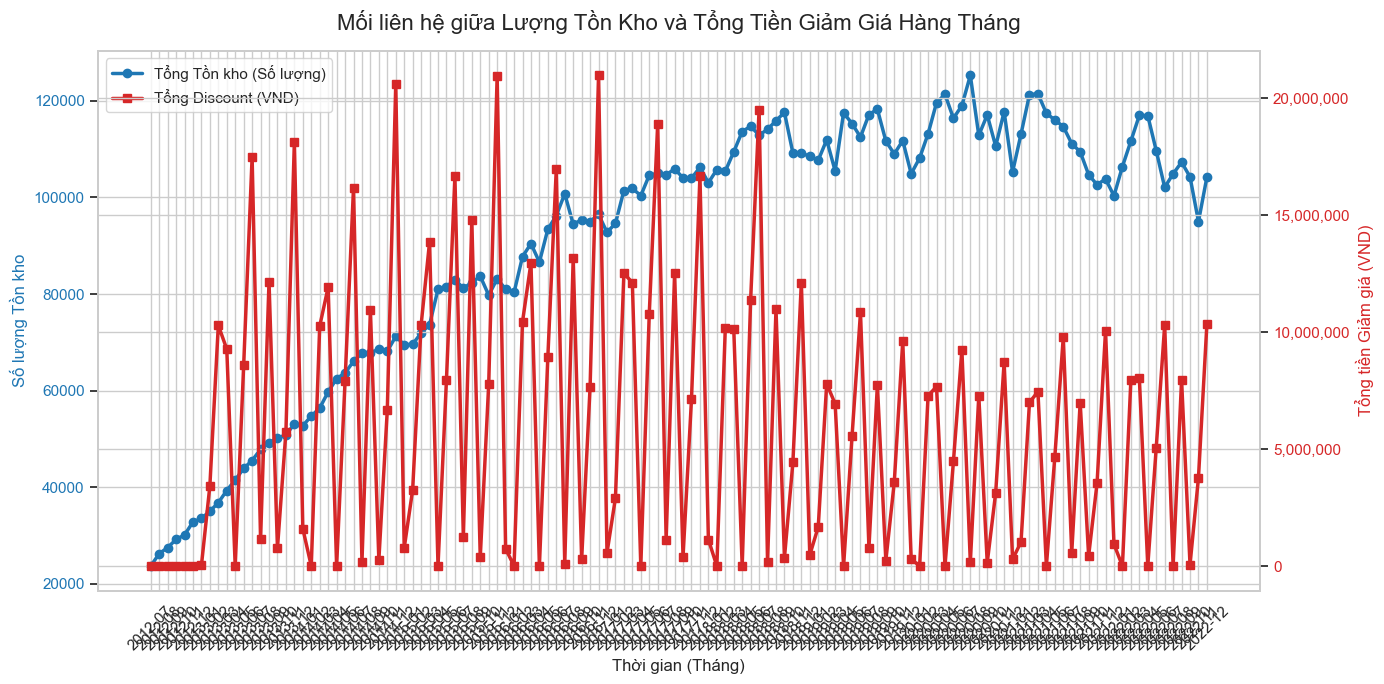

In [27]:

# Thiết lập st

# ==========================================
# 1. XỬ LÝ DỮ LIỆU TỒN KHO (INVENTORY)
# ==========================================
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['Month'] = inventory['snapshot_date'].dt.to_period('M')

# Tính tổng tồn kho theo tháng
inv_monthly = inventory.groupby('Month')['stock_on_hand'].sum().reset_index()

# ==========================================
# 2. XỬ LÝ DỮ LIỆU GIẢM GIÁ (DISCOUNT)
# ==========================================

orders['order_date'] = pd.to_datetime(orders['order_date'])

# Ghép bảng orders và order_items bằng order_id để map ngày tháng vào số tiền giảm giá
discount_df = pd.merge(
    orders[['order_id', 'order_date']], 
    order_items[['order_id', 'discount_amount']], 
    on='order_id', 
    how='inner'
)

# Chuyển đổi ngày tháng và tính tổng số tiền giảm giá theo tháng
discount_df['Month'] = discount_df['order_date'].dt.to_period('M')
disc_monthly = discount_df.groupby('Month')['discount_amount'].sum().reset_index()

# ==========================================
# 3. KẾT HỢP VÀ VẼ BIỂU ĐỒ
# ==========================================
# Gộp 2 bảng dữ liệu vào chung theo tháng
merged_df = pd.merge(inv_monthly, disc_monthly, on='Month', how='inner')
merged_df['Month_str'] = merged_df['Month'].dt.strftime('%Y-%m')

# Khởi tạo figure
fig, ax1 = plt.subplots()

x = np.arange(len(merged_df['Month_str']))

# --- Line 1: Tổng tồn kho (Trục Y bên trái) ---
ax1.plot(x, merged_df['stock_on_hand'], color='#1f77b4', marker='o', linewidth=2.5, label='Tổng Tồn kho (Số lượng)')
ax1.set_xlabel('Thời gian (Tháng)', fontsize=12)
ax1.set_ylabel('Số lượng Tồn kho', fontsize=12, color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_xticks(x)
ax1.set_xticklabels(merged_df['Month_str'], rotation=45)

# --- Line 2: Tổng số tiền giảm giá (Trục Y bên phải) ---
ax2 = ax1.twinx()
ax2.plot(x, merged_df['discount_amount'], color='#d62728', marker='s', linewidth=2.5, label='Tổng Discount (VND)')
ax2.set_ylabel('Tổng tiền Giảm giá (VND)', fontsize=12, color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')

# Format trục Y bên phải để hiển thị số tiền dễ nhìn hơn (ví dụ: chia cho 1 triệu)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Gom chú thích (legend)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.title('Mối liên hệ giữa Lượng Tồn Kho và Tổng Tiền Giảm Giá Hàng Tháng', fontsize=16, pad=15)
plt.tight_layout()
plt.show()

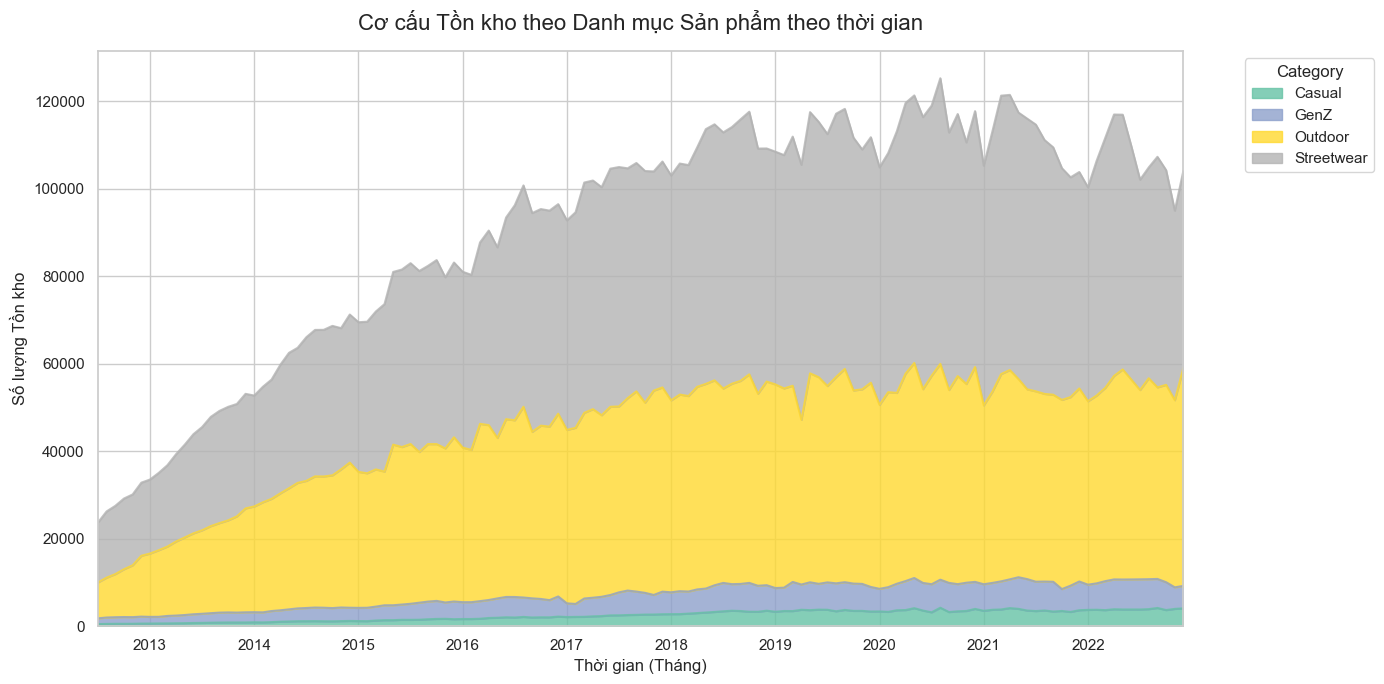

In [33]:
# Nhóm tổng tồn kho theo tháng và theo danh mục (category)
category_stock = inventory.groupby(['snapshot_date', 'category'])['stock_on_hand'].sum().reset_index()

# Chuyển đổi dữ liệu (Pivot) để các category biến thành các cột, index là ngày
pivot_stock = category_stock.pivot(index='snapshot_date', columns='category', values='stock_on_hand').fillna(0)

# Vẽ Stacked Area Chart
fig, ax = plt.subplots(figsize=(14, 7))
pivot_stock.plot.area(ax=ax, alpha=0.8, colormap='Set2')

ax.set_title('Cơ cấu Tồn kho theo Danh mục Sản phẩm theo thời gian', fontsize=16, pad=15)
ax.set_xlabel('Thời gian (Tháng)', fontsize=12)
ax.set_ylabel('Số lượng Tồn kho', fontsize=12)
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

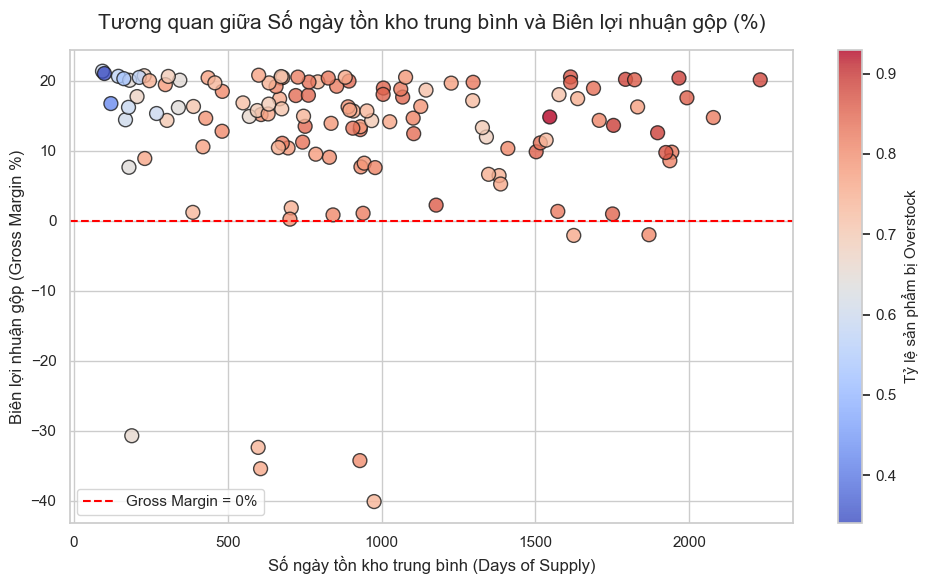

In [34]:

# Tạo cột Tháng-Năm để join với Inventory
sales['YearMonth'] = sales['Date'].dt.to_period('M')

# Nhóm doanh thu và COGS theo tháng
monthly_sales = sales.groupby('YearMonth')[['Revenue', 'COGS']].sum().reset_index()
# Tính Gross Margin % = (Doanh thu - Giá vốn) / Doanh thu
monthly_sales['Gross_Margin_Pct'] = (monthly_sales['Revenue'] - monthly_sales['COGS']) / monthly_sales['Revenue'] * 100

# 2. Xử lý bảng Inventory
inventory['YearMonth'] = inventory['snapshot_date'].dt.to_period('M')
# Tính số ngày tồn kho trung bình (hoặc lấy tổng tồn kho) và tỷ lệ overstock theo tháng
monthly_inv = inventory.groupby('YearMonth').agg(
    avg_days_of_supply=('days_of_supply', 'mean'),
    overstock_ratio=('overstock_flag', 'mean') # Tỷ lệ số mặt hàng bị đánh dấu overstock
).reset_index()

# 3. Kết hợp (Merge) 2 bảng
merged_data = pd.merge(monthly_sales, monthly_inv, on='YearMonth', how='inner')

# 4. Vẽ Scatter Plot
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    x=merged_data['avg_days_of_supply'], 
    y=merged_data['Gross_Margin_Pct'],
    c=merged_data['overstock_ratio'], # Dùng tỷ lệ overstock làm màu sắc (color map)
    cmap='coolwarm', # Màu lạnh sang nóng
    s=100, # Kích thước điểm
    edgecolor='k', alpha=0.8
)

# Thêm thanh màu (Colorbar) để chú thích tỷ lệ Overstock
cbar = plt.colorbar(scatter)
cbar.set_label('Tỷ lệ sản phẩm bị Overstock', fontsize=11)

ax.set_title('Tương quan giữa Số ngày tồn kho trung bình và Biên lợi nhuận gộp (%)', fontsize=15, pad=15)
ax.set_xlabel('Số ngày tồn kho trung bình (Days of Supply)', fontsize=12)
ax.set_ylabel('Biên lợi nhuận gộp (Gross Margin %)', fontsize=12)

# Vẽ thêm 1 đường tham chiếu ở mức y=0 (Gross Margin = 0)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Gross Margin = 0%')
ax.legend()

plt.tight_layout()
plt.show()

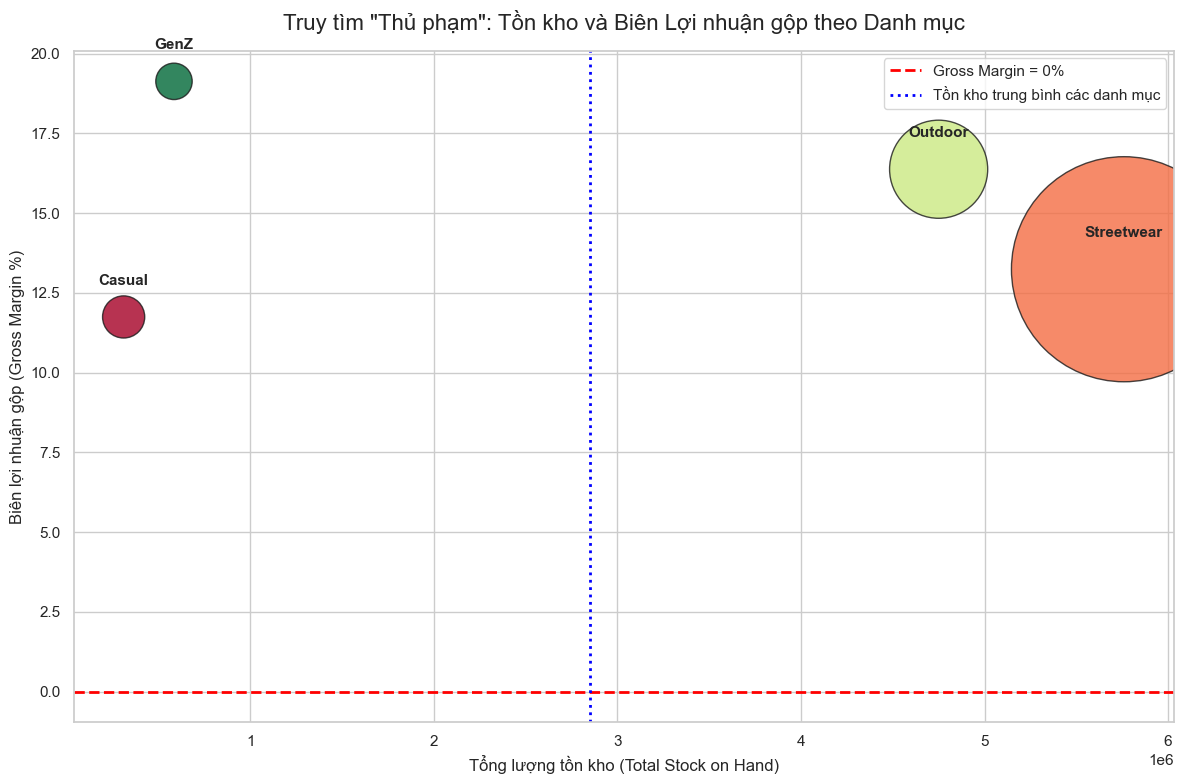

In [29]:
# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# ==========================================
# 1. TÍNH TỔNG TỒN KHO THEO DANH MỤC
# ==========================================
# Sử dụng bảng inventory.csv để lấy category và stock_on_hand [cite: 77]
inv_by_category = inventory.groupby('category')['stock_on_hand'].sum().reset_index()
inv_by_category.rename(columns={'stock_on_hand': 'total_stock'}, inplace=True)

# Join chi tiết đơn hàng với thông tin sản phẩm để lấy giá vốn (cogs) và category [cite: 65, 71]
merged_sales = pd.merge(order_items, products, on='product_id', how='inner')

# Tính Doanh thu và Giá vốn cho từng dòng
# Cột unit_price đã là "đơn giá sau khi áp dụng khuyến mãi" 
merged_sales['line_revenue'] = merged_sales['quantity'] * merged_sales['unit_price']
merged_sales['line_cogs'] = merged_sales['quantity'] * merged_sales['cogs']

# Gom nhóm theo danh mục
sales_by_category = merged_sales.groupby('category')[['line_revenue', 'line_cogs']].sum().reset_index()

# Tính tỷ lệ phần trăm Gross Margin
sales_by_category['gross_margin_pct'] = (sales_by_category['line_revenue'] - sales_by_category['line_cogs']) / sales_by_category['line_revenue'] * 100

# ==========================================
# 3. KẾT HỢP DỮ LIỆU & VẼ BIỂU ĐỒ
# ==========================================
final_df = pd.merge(inv_by_category, sales_by_category, on='category', how='inner')

fig, ax = plt.subplots()

# Kích thước bọt khí (s) thể hiện mức độ đóng góp doanh thu (được chia tỷ lệ để vừa khung hình)
scatter = ax.scatter(
    final_df['total_stock'], 
    final_df['gross_margin_pct'], 
    s=final_df['line_revenue'] / 500000, 
    c=final_df['gross_margin_pct'], 
    cmap='RdYlGn', # Màu chuyển từ Đỏ (âm) sang Xanh lá (dương)
    alpha=0.8, 
    edgecolors='k'
)

# Gắn nhãn tên Category cho từng điểm để nhận diện ngay lập tức
for i in range(len(final_df)):
    ax.text(
        final_df['total_stock'].iloc[i], 
        final_df['gross_margin_pct'].iloc[i] + 1, # Đẩy nhãn lên cao một chút cho khỏi đè vào điểm
        final_df['category'].iloc[i], 
        fontsize=11, ha='center', fontweight='bold'
    )

# Thêm các đường tham chiếu để tạo thành 4 góc phần tư (Quadrants)
ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Gross Margin = 0%')
ax.axvline(final_df['total_stock'].mean(), color='blue', linestyle=':', linewidth=2, label='Tồn kho trung bình các danh mục')

ax.set_title('Truy tìm "Thủ phạm": Tồn kho và Biên Lợi nhuận gộp theo Danh mục', fontsize=16, pad=15)
ax.set_xlabel('Tổng lượng tồn kho (Total Stock on Hand)', fontsize=12)
ax.set_ylabel('Biên lợi nhuận gộp (Gross Margin %)', fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

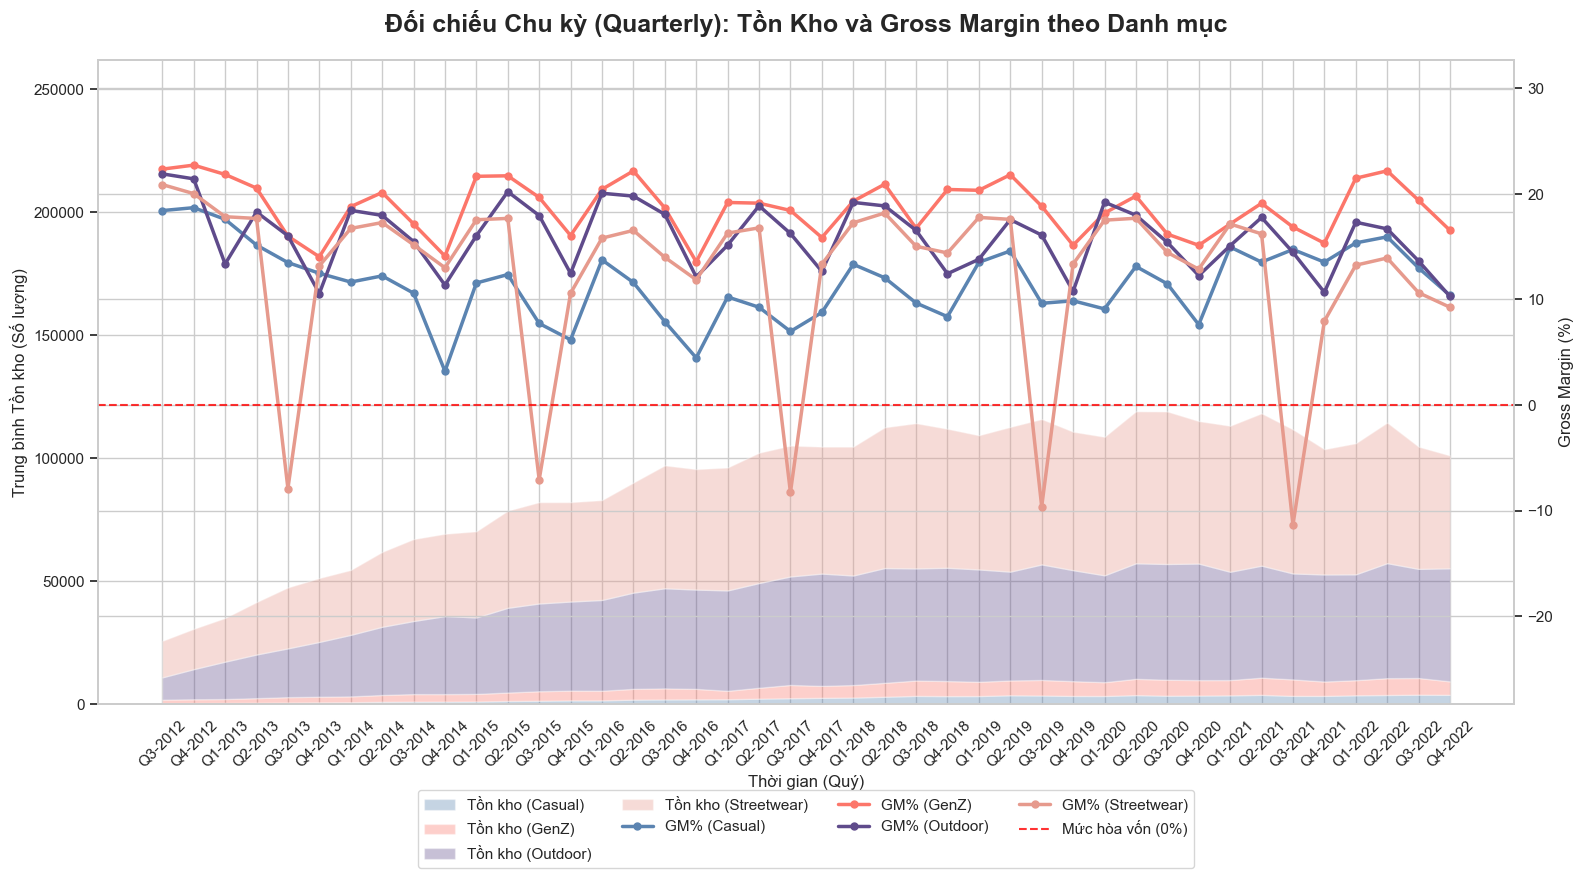

In [38]:
# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 8)

# ==========================================
# 1. TÍNH TỒN KHO THEO QUÝ (AREA CHART) - CẬP NHẬT LOGIC CHUẨN
# ==========================================
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['Month'] = inventory['snapshot_date'].dt.to_period('M')
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')

# BƯỚC 1: Tính TỔNG tồn kho của toàn bộ Category trong từng THÁNG
inv_monthly_total = inventory.groupby(['Quarter', 'Month', 'category'])['stock_on_hand'].sum().reset_index()

# BƯỚC 2: Tính TRUNG BÌNH của các tháng đó để ra tồn kho trung bình của QUÝ
inv_quarterly = inv_monthly_total.groupby(['Quarter', 'category'])['stock_on_hand'].mean().reset_index()

# Chuyển đổi để mỗi Category thành 1 cột
inv_pivot = inv_quarterly.pivot(index='Quarter', columns='category', values='stock_on_hand').fillna(0)

# ==========================================
# 2. TÍNH LỢI NHUẬN GỘP THEO QUÝ (LINE CHART)
# ==========================================
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Quarter'] = orders['order_date'].dt.to_period('Q')

# Ghép 3 bảng
sales_df = order_items.merge(products, on='product_id').merge(orders[['order_id', 'Quarter']], on='order_id')
sales_df['revenue'] = sales_df['quantity'] * sales_df['unit_price']
sales_df['cogs_total'] = sales_df['quantity'] * sales_df['cogs']

# Nhóm Doanh thu và Giá vốn theo Quý
gm_quarterly = sales_df.groupby(['Quarter', 'category'])[['revenue', 'cogs_total']].sum().reset_index()
gm_quarterly['gm_pct'] = (gm_quarterly['revenue'] - gm_quarterly['cogs_total']) / gm_quarterly['revenue'] * 100
gm_pivot = gm_quarterly.pivot(index='Quarter', columns='category', values='gm_pct').fillna(0)

# ==========================================
# 3. KẾT HỢP VÀ VẼ ĐỒ THỊ
# ==========================================
common_quarters = inv_pivot.index.intersection(gm_pivot.index)
inv_pivot = inv_pivot.loc[common_quarters]
gm_pivot = gm_pivot.loc[common_quarters]
categories = inv_pivot.columns

fig, ax1 = plt.subplots(figsize=(16, 9)) # Tăng chiều cao thêm một chút

colors = ['#5b84b1', '#fc766aff', '#5f4b8bff', '#e69a8dff']
x = np.arange(len(common_quarters))

# --- VẼ AREA CHART: Tồn kho xếp chồng (Trục Y trái) ---
# Dùng stackplot để vẽ biểu đồ miền xếp chồng thay vì bar chart
ax1.stackplot(
    x, 
    [inv_pivot[cat] for cat in categories], 
    labels=[f'Tồn kho ({cat})' for cat in categories], 
    colors=colors, 
    alpha=0.35 # Làm mờ màu đi một chút để trông sang hơn
)

# --- VẼ LINE CHART: Chu kỳ Gross Margin (Trục Y phải) ---
ax2 = ax1.twinx()
for i, cat in enumerate(categories):
    if cat in gm_pivot.columns:
        ax2.plot(x, gm_pivot[cat], label=f'GM% ({cat})', color=colors[i % len(colors)], marker='o', markersize=5, linewidth=2.5)

# --- THỦ THUẬT TÁCH RỜI 2 BIỂU ĐỒ ---
# 1. Ép biểu đồ miền (ax1) dẹt xuống dưới cùng bằng cách nhân đôi trần trục Y
max_inv = inv_pivot.sum(axis=1).max()
ax1.set_ylim(0, max_inv * 2.2) 

# 2. Đẩy biểu đồ đường (ax2) lên trên cùng bằng cách khoét sâu đáy trục Y
min_gm = gm_pivot.min().min() # Đáy sâu nhất (ví dụ: -60%)
max_gm = gm_pivot.max().max() # Đỉnh cao nhất (ví dụ: 30%)
# Đặt giới hạn dưới cực sâu (gấp 2.5 lần đáy) để toàn bộ đường đồ thị nổi lên nửa trên
ax2.set_ylim(min_gm * 2.5, max_gm + 10) 

# --- ĐỊNH DẠNG NHÃN VÀ TRỤC ---
ax1.set_xlabel('Thời gian (Quý)', fontsize=12)
ax1.set_ylabel('Trung bình Tồn kho (Số lượng)', fontsize=12)
ax2.set_ylabel('Gross Margin (%)', fontsize=12)

# Chuyển đổi định dạng nhãn trục X sang dạng Q1-2023, Q2-2023...
ax1.set_xticks(x)
ax1.set_xticklabels([f"Q{q.quarter}-{q.year}" for q in common_quarters], rotation=45)

# Vẽ đường cơ sở 0% màu đỏ cho ax2
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='Mức hòa vốn (0%)')

# Gom chú thích
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=11)

plt.title('Đối chiếu Chu kỳ (Quarterly): Tồn Kho và Gross Margin theo Danh mục', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

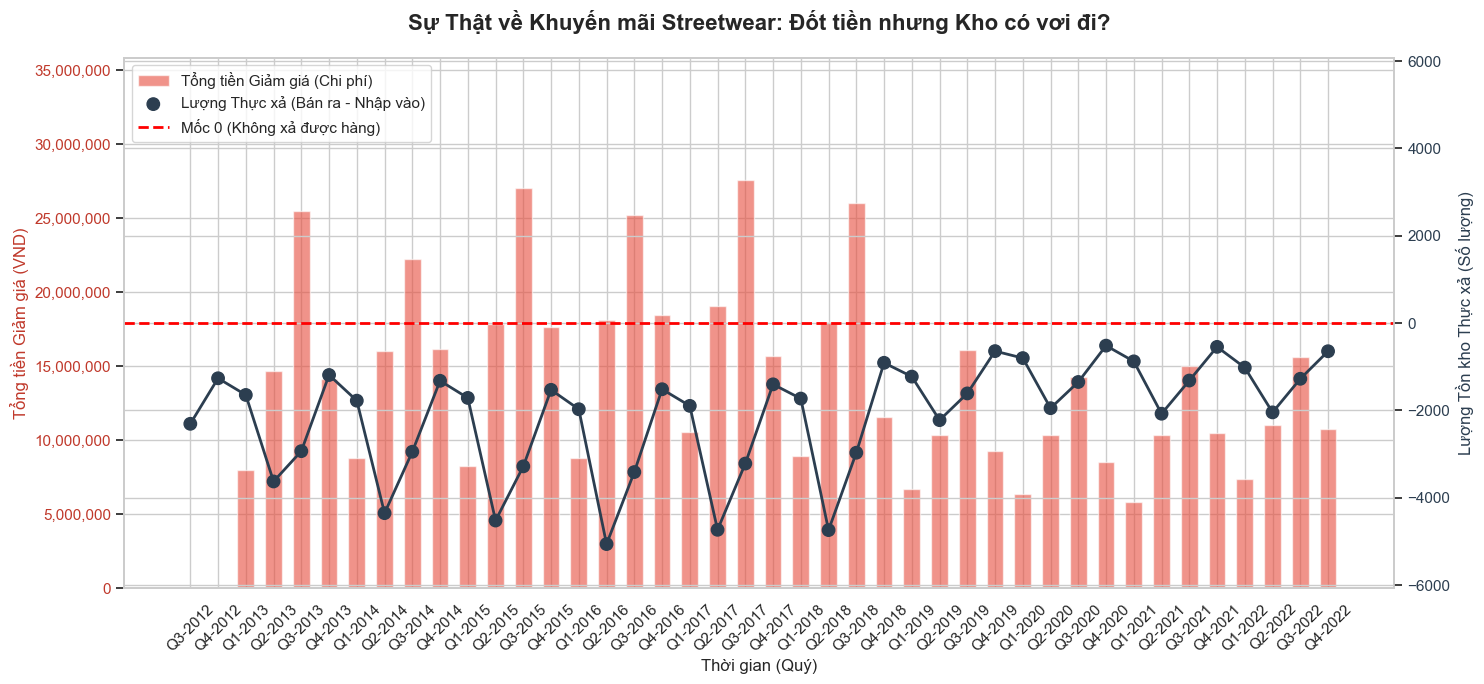

In [43]:

# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

# ==========================================
# 1. TÍNH TỔNG TIỀN GIẢM GIÁ (TỪ BẢNG ORDERS & ITEMS)
# ==========================================
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Quarter'] = orders['order_date'].dt.to_period('Q')

# Ghép bảng và lọc Streetwear
df_sales = order_items.merge(products, on='product_id').merge(orders[['order_id', 'Quarter']], on='order_id')
sw_sales = df_sales[df_sales['category'] == 'Streetwear']

disc_quarterly = sw_sales.groupby('Quarter')['discount_amount'].sum().reset_index()

# ==========================================
# 2. TÍNH LƯỢNG TỒN KHO THỰC XẢ (TỪ BẢNG INVENTORY)
# ==========================================
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')

# Lọc Streetwear và tính tổng nhập/bán theo Quý
sw_inv = inventory[inventory['category'] == 'Streetwear']
inv_quarterly = sw_inv.groupby('Quarter')[['units_sold', 'units_received']].sum().reset_index()

# Tính Lượng Thực Xả (Net Cleared)
inv_quarterly['net_cleared'] = inv_quarterly['units_sold'] - inv_quarterly['units_received']

# ==========================================
# 3. KẾT HỢP VÀ VẼ ĐỒ THỊ
# ==========================================
merged_df = pd.merge(disc_quarterly, inv_quarterly, on='Quarter', how='inner')

fig, ax1 = plt.subplots(figsize=(15, 7))

x = np.arange(len(merged_df['Quarter']))
quarters_str = [f"Q{q.quarter}-{q.year}" for q in merged_df['Quarter']]

# --- BAR CHART: TỔNG TIỀN GIẢM GIÁ (Trục Y trái) ---
ax1.bar(x, merged_df['discount_amount'], color='#e74c3c', alpha=0.6, width=0.6, label='Tổng tiền Giảm giá (Chi phí)')
ax1.set_xlabel('Thời gian (Quý)', fontsize=12)
ax1.set_ylabel('Tổng tiền Giảm giá (VND)', fontsize=12, color='#c0392b')
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.set_xticks(x)
ax1.set_xticklabels(quarters_str, rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f}".format(val)))

# --- LINE CHART: LƯỢNG THỰC XẢ (Trục Y phải) ---
ax2 = ax1.twinx()

# Phân loại màu sắc cho đường Line: Xanh nếu xả được hàng (>0), Đen nếu kho vẫn phình to (<0)
colors = ['#27ae60' if val > 0 else '#2c3e50' for val in merged_df['net_cleared']]

ax2.plot(x, merged_df['net_cleared'], color='#2c3e50', linewidth=2, zorder=1) # Vẽ đường nối
ax2.scatter(x, merged_df['net_cleared'], color=colors, s=80, zorder=2, label='Lượng Thực xả (Bán ra - Nhập vào)')

ax2.set_ylabel('Lượng Tồn kho Thực xả (Số lượng)', fontsize=12, color='#2c3e50')
ax2.tick_params(axis='y', labelcolor='#2c3e50')

# VẼ ĐƯỜNG RANH GIỚI SINH TỬ (Mốc 0)
ax2.axhline(0, color='red', linestyle='--', linewidth=2, label='Mốc 0 (Không xả được hàng)')

# Tinh chỉnh giới hạn trục Y
ax1.set_ylim(0, merged_df['discount_amount'].max() * 1.3)
# Đảm bảo trục Y bên phải hiển thị rõ cả phần âm và phần dương
max_abs_val = max(abs(merged_df['net_cleared'].max()), abs(merged_df['net_cleared'].min()))
ax2.set_ylim(-max_abs_val * 1.2, max_abs_val * 1.2)

# Gom chú thích
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

plt.title('Sự Thật về Khuyến mãi Streetwear: Đốt tiền nhưng Kho có vơi đi?', fontsize=16, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

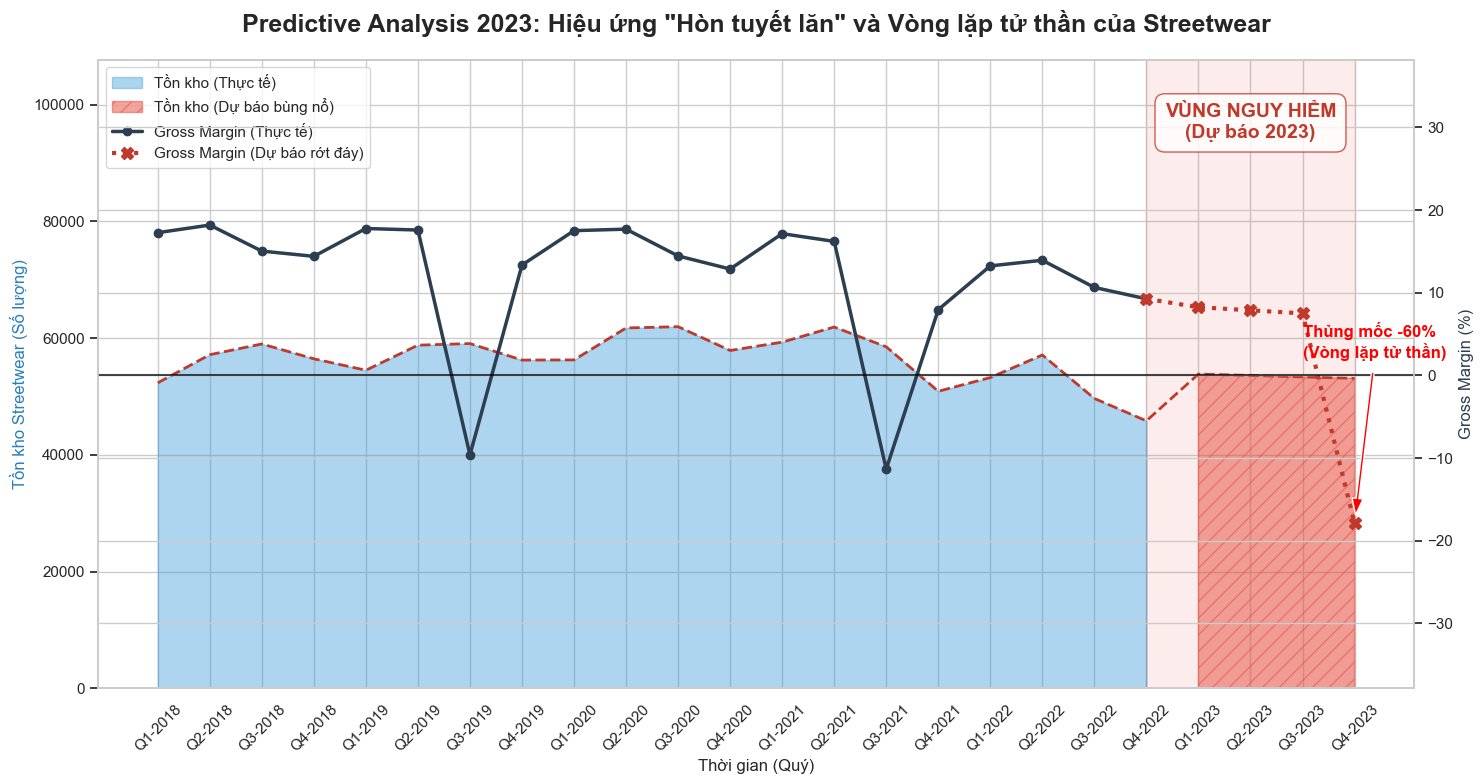

In [47]:
# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

# ==========================================
# 1. TÍNH TOÁN DỮ LIỆU LỊCH SỬ (Đến hết 2022)
# ==========================================

# Xử lý thời gian
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Quarter'] = orders['order_date'].dt.to_period('Q')
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['Month'] = inventory['snapshot_date'].dt.to_period('M')
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')

# LỌC RIÊNG STREETWEAR
sw_inv = inventory[inventory['category'] == 'Streetwear']
df_sales = order_items.merge(products, on='product_id').merge(orders[['order_id', 'Quarter']], on='order_id')
sw_sales = df_sales[df_sales['category'] == 'Streetwear'].copy()

# Tính Tồn kho lịch sử
inv_monthly = sw_inv.groupby(['Quarter', 'Month'])['stock_on_hand'].sum().reset_index()
hist_inv = inv_monthly.groupby('Quarter')['stock_on_hand'].mean().reset_index()

# Tính Gross Margin lịch sử
sw_sales['revenue'] = sw_sales['quantity'] * sw_sales['unit_price']
sw_sales['cogs_total'] = sw_sales['quantity'] * sw_sales['cogs']
hist_gm = sw_sales.groupby('Quarter')[['revenue', 'cogs_total']].sum().reset_index()
hist_gm['gm_pct'] = (hist_gm['revenue'] - hist_gm['cogs_total']) / hist_gm['revenue'] * 100

# Gộp dữ liệu lịch sử
df_hist = pd.merge(hist_inv, hist_gm[['Quarter', 'gm_pct']], on='Quarter', how='inner')
# Lọc từ năm 2018 trở đi để thấy rõ đà tăng tốc của "hòn tuyết lăn"
df_hist = df_hist[df_hist['Quarter'] >= '2018Q1'].reset_index(drop=True)

# ==========================================
# 2. NGOẠI SUY & DỰ BÁO CHO NĂM 2023 (PREDICTIVE)
# ==========================================
# Tạo các quý của năm 2023
quarters_2023 = pd.period_range(start='2023Q1', end='2023Q4', freq='Q')
x_hist = np.arange(len(df_hist))
x_pred = np.arange(len(df_hist), len(df_hist) + 4)

# Mô hình hóa đà tăng Tồn kho (Dùng hồi quy bậc 1)
z_inv = np.polyfit(x_hist, df_hist['stock_on_hand'], 1)
p_inv = np.poly1d(z_inv)
pred_inv = p_inv(x_pred)

# Mô hình hóa đà giảm Margin (Dự báo xu hướng giảm dần của các đáy)
z_gm = np.polyfit(x_hist, df_hist['gm_pct'], 1)
p_gm = np.poly1d(z_gm)
# Thêm "cú shock mùa vụ" cho quý 4/2023 để mô phỏng "Vòng lặp tử thần"
pred_gm = p_gm(x_pred)
pred_gm[-1] -= 25  # Ép Gross Margin Q4-2023 rớt thảm hại do áp lực xả kho khổng lồ

# ==========================================
# 3. VẼ BIỂU ĐỒ TRỰC QUAN HÓA CẢNH BÁO
# ==========================================
fig, ax1 = plt.subplots()

# Nối trục X
all_x = np.concatenate([x_hist, x_pred])
all_quarters = [f"Q{q.quarter}-{q.year}" for q in df_hist['Quarter']] + [f"Q{q.quarter}-{q.year}" for q in quarters_2023]

# --- VẼ TỒN KHO (HIỆU ỨNG HÒN TUYẾT LĂN) ---
# Tồn kho lịch sử
ax1.fill_between(x_hist, 0, df_hist['stock_on_hand'], color='#3498db', alpha=0.4, label='Tồn kho (Thực tế)')
# Tồn kho dự báo 2023
ax1.fill_between(x_pred, 0, pred_inv, color='#e74c3c', alpha=0.5, hatch='//', label='Tồn kho (Dự báo bùng nổ)')
ax1.plot(all_x, np.concatenate([df_hist['stock_on_hand'], pred_inv]), color='#c0392b', linestyle='--', linewidth=2)

ax1.set_xlabel('Thời gian (Quý)', fontsize=12)
ax1.set_ylabel('Tồn kho Streetwear (Số lượng)', fontsize=12, color='#2980b9')
ax1.set_ylim(0, max(pred_inv) * 2.0) # Đẩy dẹt xuống để nhường chỗ cho Line chart

# --- VẼ GROSS MARGIN (VÒNG LẶP TỬ THẦN) ---
ax2 = ax1.twinx()
# Lịch sử
ax2.plot(x_hist, df_hist['gm_pct'], color='#2c3e50', marker='o', linewidth=2.5, label='Gross Margin (Thực tế)')
# Dự báo
ax2.plot(np.concatenate([x_hist[-1:], x_pred]), np.concatenate([df_hist['gm_pct'].tail(1), pred_gm]), 
         color='#c0392b', marker='X', markersize=8, linestyle=':', linewidth=3, label='Gross Margin (Dự báo rớt đáy)')

# Đường ranh giới hòa vốn
ax2.axhline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
ax2.set_ylabel('Gross Margin (%)', fontsize=12, color='#2c3e50')
ax2.set_ylim(min(pred_gm) - 20, max(df_hist['gm_pct']) + 20)

# --- VÙNG CẢNH BÁO (DANGER ZONE) ---
ax1.axvspan(x_hist[-1], x_pred[-1], color='#e74c3c', alpha=0.1)
plt.text(x_pred[1], ax2.get_ylim()[1]*0.8, 'VÙNG NGUY HIỂM\n(Dự báo 2023)', 
         color='#c0392b', fontsize=14, fontweight='bold', ha='center', va='center',
         bbox=dict(facecolor='white', edgecolor='#c0392b', boxstyle='round,pad=0.5', alpha=0.8))

# Mũi tên chỉ vào đáy Q4-2023
ax2.annotate('Thủng mốc -60%\n(Vòng lặp tử thần)', xy=(x_pred[-1], pred_gm[-1]), 
             xytext=(x_pred[-2], pred_gm[-1] + 20),
             arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
             fontsize=12, color='red', fontweight='bold')

# Nhãn trục X
ax1.set_xticks(all_x)
ax1.set_xticklabels(all_quarters, rotation=45)

# Gom legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11)

plt.title('Predictive Analysis 2023: Hiệu ứng "Hòn tuyết lăn" và Vòng lặp tử thần của Streetwear', fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

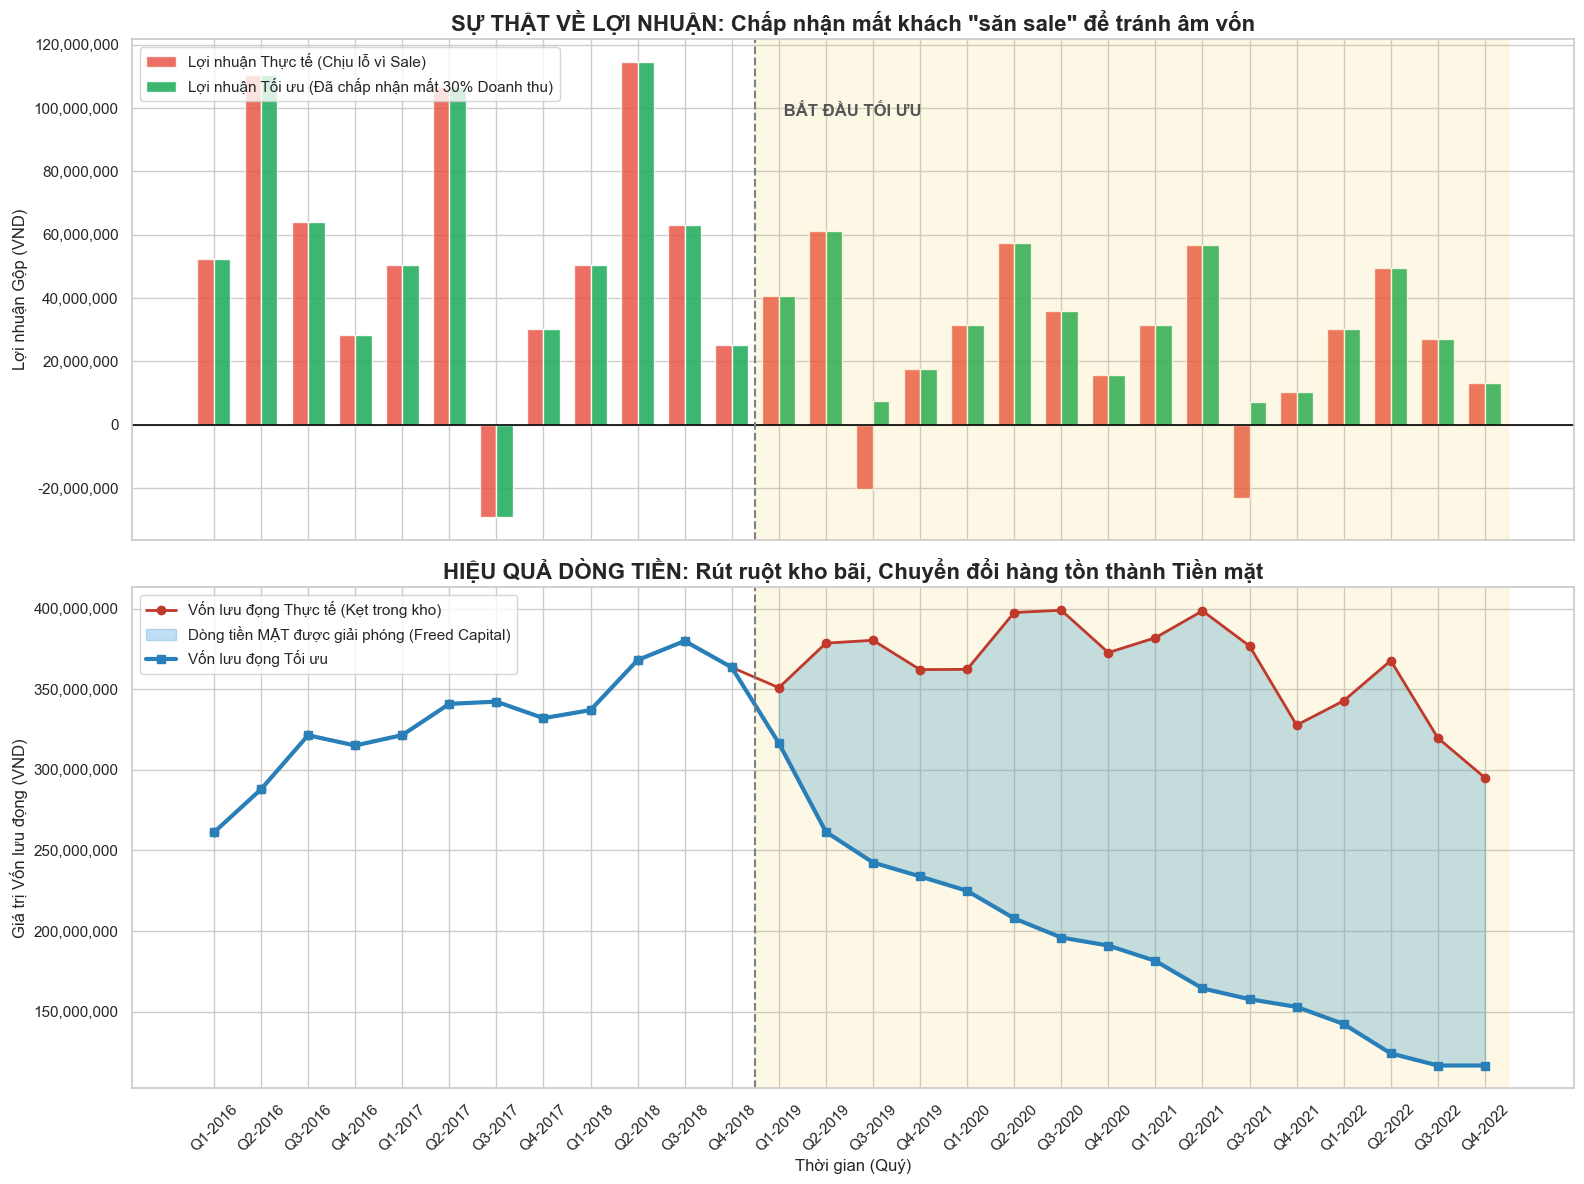

In [56]:
# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU ĐẾN MỨC PHÂN KHÚC (SEGMENT)
# ==========================================

orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Quarter'] = orders['order_date'].dt.to_period('Q')
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')
inventory['Month'] = inventory['snapshot_date'].dt.to_period('M')

# --- Dữ liệu Streetwear theo Segment ---
sw_sales = order_items.merge(products, on='product_id').merge(orders[['order_id', 'Quarter']], on='order_id')
sw_sales = sw_sales[sw_sales['category'] == 'Streetwear'].copy()

# Tính giá vốn trung bình (Average COGS) để định giá tồn kho
avg_cogs = sw_sales['cogs'].mean()

sw_sales['actual_revenue'] = sw_sales['quantity'] * sw_sales['unit_price']
sw_sales['actual_cogs_total'] = sw_sales['quantity'] * sw_sales['cogs']

df_financials_seg = sw_sales.groupby(['Quarter', 'segment'])[['actual_revenue', 'actual_cogs_total', 'quantity']].sum().reset_index()
df_financials_seg['actual_profit'] = df_financials_seg['actual_revenue'] - df_financials_seg['actual_cogs_total']
df_financials_seg['actual_gm_pct'] = df_financials_seg['actual_profit'] / df_financials_seg['actual_revenue'] * 100

# Tính Tồn kho theo Segment
sw_inv = inventory[inventory['category'] == 'Streetwear']
inv_monthly_seg = sw_inv.groupby(['Quarter', 'Month', 'segment'])[['stock_on_hand', 'units_sold', 'units_received']].sum().reset_index()
df_inv_seg = inv_monthly_seg.groupby(['Quarter', 'segment']).agg(
    actual_stock=('stock_on_hand', 'mean'),
    actual_received=('units_received', 'sum')
).reset_index()

# Gộp bảng
df_sim_seg = pd.merge(df_inv_seg, df_financials_seg, on=['Quarter', 'segment'], how='inner')
df_sim_seg = df_sim_seg[df_sim_seg['Quarter'] >= '2016Q1'].reset_index(drop=True)

# ==========================================
# 2. CHẠY MÔ PHỎNG TỐI ƯU HÓA NHẮM MỤC TIÊU (Áp dụng từ 2019Q1)
# ==========================================
start_q = pd.Period('2019Q1', freq='Q')

# Ép kiểu float giống code trước để tránh lỗi LossySetitemError
df_sim_seg['opt_revenue'] = df_sim_seg['actual_revenue'].astype(float)
df_sim_seg['opt_profit'] = df_sim_seg['actual_profit'].astype(float)
df_sim_seg['opt_stock'] = df_sim_seg['actual_stock'].astype(float)
df_sim_seg['opt_sold_qty'] = df_sim_seg['quantity'].astype(float)

segments = df_sim_seg['segment'].unique()

for seg in segments:
    seg_mask = df_sim_seg['segment'] == seg
    idx_list = df_sim_seg[seg_mask].index.tolist()
    
    start_idx_list = df_sim_seg[(seg_mask) & (df_sim_seg['Quarter'] == start_q)].index
    if len(start_idx_list) == 0: continue
    start_idx = start_idx_list[0]
    
    current_stock = df_sim_seg.loc[start_idx - 1, 'actual_stock']
    
    for i in idx_list:
        if df_sim_seg.loc[i, 'Quarter'] >= start_q:
            
            # QUY TẮC 1: SÀN LỢI NHUẬN & HÌNH PHẠT DOANH THU (Đã trả lại nguyên bản code của bạn)
            if df_sim_seg.loc[i, 'actual_gm_pct'] < 0:
                # Giả định: Mất 30% khách hàng (khối lượng bán giảm 30%) vì không giảm giá sâu
                df_sim_seg.loc[i, 'opt_sold_qty'] = df_sim_seg.loc[i, 'quantity'] * 0.7
                df_sim_seg.loc[i, 'opt_revenue'] = df_sim_seg.loc[i, 'actual_revenue'] * 0.7
                # Chốt lợi nhuận gộp ở mức +5% trên phần doanh thu còn lại
                df_sim_seg.loc[i, 'opt_profit'] = df_sim_seg.loc[i, 'opt_revenue'] * 0.05
            else:
                # Nếu đang có lãi, mọi thứ giữ nguyên
                pass
            
            # QUY TẮC 2: SIẾT NHẬP HÀNG NHẮM MỤC TIÊU
            if seg in ['Performance', 'Everyday']:
                # Hạn chế nhập các segment tồn kho nhiều (chỉ nhập 70%)
                opt_received = df_sim_seg.loc[i, 'opt_sold_qty'] * 0.7
            else:
                # Các segment khác vẫn nhập bình thường (nhập 100%)
                opt_received = df_sim_seg.loc[i, 'opt_sold_qty'] * 1.0
                
            current_stock = current_stock + opt_received - df_sim_seg.loc[i, 'opt_sold_qty']
            df_sim_seg.loc[i, 'opt_stock'] = max(current_stock, 0)

# ==========================================
# 3. GỘP (ROLL-UP) LẠI VÀ TÍNH VỐN LƯU ĐỌNG
# ==========================================
df_final = df_sim_seg.groupby('Quarter').agg(
    actual_stock=('actual_stock', 'sum'),
    opt_stock=('opt_stock', 'sum'),
    actual_profit=('actual_profit', 'sum'),
    opt_profit=('opt_profit', 'sum'),
    actual_revenue=('actual_revenue', 'sum'),
    opt_revenue=('opt_revenue', 'sum')
).reset_index()

# Tính toán giá trị vốn lưu đọng (TRAPPED CAPITAL)
df_final['actual_trapped_capital'] = df_final['actual_stock'] * avg_cogs
df_final['opt_trapped_capital'] = df_final['opt_stock'] * avg_cogs
df_final['freed_capital'] = df_final['actual_trapped_capital'] - df_final['opt_trapped_capital']

# ==========================================
# 4. VẼ DASHBOARD CỦA BẠN
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
x = np.arange(len(df_final))
width = 0.35

start_idx_plot = df_final.index[df_final['Quarter'] == start_q].tolist()[0]

# --- BIỂU ĐỒ 1: SO SÁNH LỢI NHUẬN TUYỆT ĐỐI ---
ax1.bar(x - width/2, df_final['actual_profit'], width, label='Lợi nhuận Thực tế (Chịu lỗ vì Sale)', color='#e74c3c', alpha=0.8)
ax1.bar(x + width/2, df_final['opt_profit'], width, label='Lợi nhuận Tối ưu (Đã chấp nhận mất 30% Doanh thu)', color='#27ae60', alpha=0.9)

ax1.axhline(0, color='black', linestyle='-', linewidth=1.2)
ax1.axvspan(start_idx_plot - 0.5, x[-1] + 0.5, color='#f1c40f', alpha=0.1)
ax1.axvline(start_idx_plot - 0.5, color='gray', linestyle='--', linewidth=1.5)
ax1.text(start_idx_plot, ax1.get_ylim()[1]*0.8, ' BẮT ĐẦU TỐI ƯU', color='#555555', fontweight='bold')

ax1.set_title('SỰ THẬT VỀ LỢI NHUẬN: Chấp nhận mất khách "săn sale" để tránh âm vốn', fontsize=16, fontweight='bold')
ax1.set_ylabel('Lợi nhuận Gộp (VND)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f}".format(val)))
ax1.legend(loc='upper left', fontsize=11)

# --- BIỂU ĐỒ 2: GIẢI PHÓNG VỐN LƯU ĐỌNG BẰNG HÀNG TỒN KHO ---
ax2.plot(x, df_final['actual_trapped_capital'], color='#c0392b', marker='o', linewidth=2, label='Vốn lưu đọng Thực tế (Kẹt trong kho)')
ax2.fill_between(x, df_final['opt_trapped_capital'], df_final['actual_trapped_capital'], where=(x >= start_idx_plot), color='#3498db', alpha=0.3, label='Dòng tiền MẶT được giải phóng (Freed Capital)')
ax2.plot(x, df_final['opt_trapped_capital'], color='#2980b9', marker='s', linewidth=3, label='Vốn lưu đọng Tối ưu')

ax2.axvspan(start_idx_plot - 0.5, x[-1] + 0.5, color='#f1c40f', alpha=0.1)
ax2.axvline(start_idx_plot - 0.5, color='gray', linestyle='--', linewidth=1.5)

ax2.set_title('HIỆU QUẢ DÒNG TIỀN: Rút ruột kho bãi, Chuyển đổi hàng tồn thành Tiền mặt', fontsize=16, fontweight='bold')
ax2.set_ylabel('Giá trị Vốn lưu đọng (VND)', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f}".format(val)))
ax2.legend(loc='upper left', fontsize=11)

plt.xticks(x, [f"Q{q.quarter}-{q.year}" for q in df_final['Quarter']], rotation=45)
plt.xlabel('Thời gian (Quý)', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_41552\2200773630.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


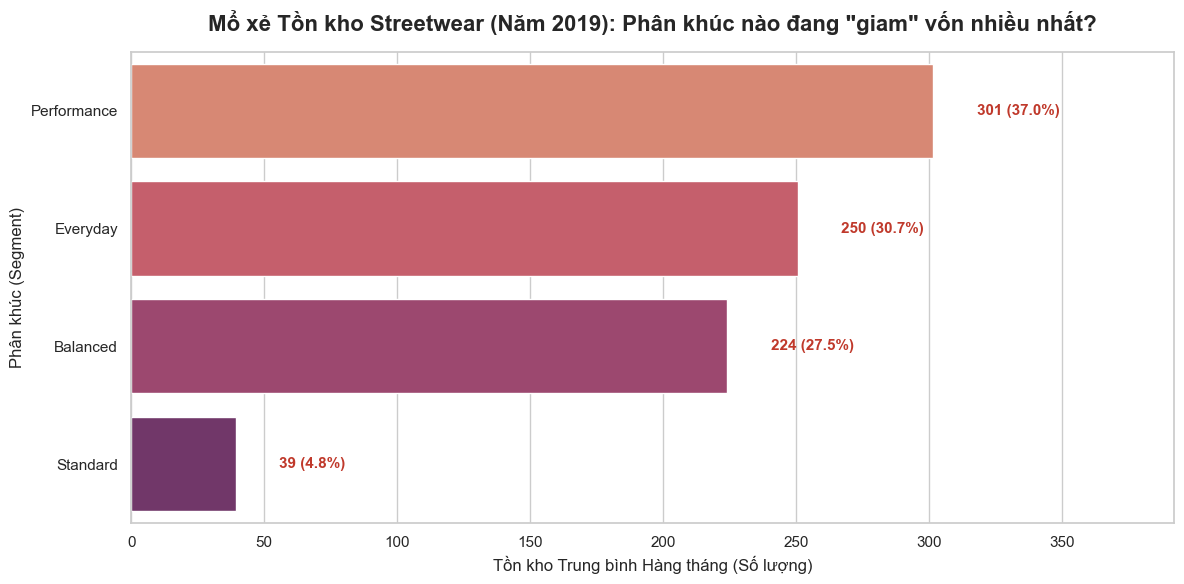

In [54]:

# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ==========================================
# 1. ĐỌC VÀ LỌC DỮ LIỆU
# ==========================================
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Lọc riêng Streetwear VÀ thu hẹp vào năm 2019 theo gợi ý của bạn
sw_inv_2019 = inventory[(inventory['category'] == 'Streetwear') & (inventory['snapshot_date'].dt.year == 2019)].copy()

# ==========================================
# 2. TÍNH TOÁN THEO LOGIC CHUẨN (DÙNG MEAN)
# ==========================================
# Dùng .mean() để tính Trung bình Tồn kho hàng tháng trong năm 2019 của từng Segment
segment_stock = sw_inv_2019.groupby('segment')['stock_on_hand'].mean().reset_index()

# Sắp xếp từ cao xuống thấp
segment_stock = segment_stock.sort_values(by='stock_on_hand', ascending=False)

# Tính tỷ trọng Phần trăm (%) dựa trên tổng trung bình
total_sw_stock = segment_stock['stock_on_hand'].sum()
segment_stock['percentage'] = (segment_stock['stock_on_hand'] / total_sw_stock) * 100

# ==========================================
# 3. VẼ BIỂU ĐỒ BÓC TÁCH (DRILL-DOWN)
# ==========================================
fig, ax = plt.subplots()

# Vẽ Bar Chart ngang
bars = sns.barplot(
    data=segment_stock, 
    x='stock_on_hand', 
    y='segment', 
    palette='flare', # Dùng tone màu nóng để cảnh báo
    ax=ax
)

# Thêm nhãn số lượng và phần trăm vào đuôi mỗi cột
for i, p in enumerate(bars.patches):
    width = p.get_width()
    percentage = segment_stock.iloc[i]['percentage']
    ax.text(
        width + (total_sw_stock * 0.02), # Đẩy chữ ra xa một chút cho thoáng
        p.get_y() + p.get_height() / 2,
        f"{int(width):,} ({percentage:.1f}%)", 
        ha="left", va="center", fontweight='bold', fontsize=11, color='#c0392b'
    )

ax.set_title('Mổ xẻ Tồn kho Streetwear (Năm 2019): Phân khúc nào đang "giam" vốn nhiều nhất?', fontsize=16, pad=15, fontweight='bold')
ax.set_xlabel('Tồn kho Trung bình Hàng tháng (Số lượng)', fontsize=12)
ax.set_ylabel('Phân khúc (Segment)', fontsize=12)

# Nới rộng giới hạn trục X để chữ không bị cắt khỏi khung hình
ax.set_xlim(0, segment_stock['stock_on_hand'].max() * 1.3)

plt.tight_layout()
plt.show()

In [52]:
# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU LỊCH SỬ
# ==========================================

orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['Quarter'] = orders['order_date'].dt.to_period('Q')
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')
inventory['Month'] = inventory['snapshot_date'].dt.to_period('M')

# Lấy dữ liệu Streetwear
sw_sales = order_items.merge(products, on='product_id').merge(orders[['order_id', 'Quarter']], on='order_id')
sw_sales = sw_sales[sw_sales['category'] == 'Streetwear'].copy()

# Tính giá vốn trung bình (Average COGS) của 1 sản phẩm Streetwear để định giá tồn kho
avg_cogs = sw_sales['cogs'].mean()

# Tính Doanh thu và Lợi nhuận Gộp tuyệt đối
sw_sales['actual_revenue'] = sw_sales['quantity'] * sw_sales['unit_price']
sw_sales['actual_cogs_total'] = sw_sales['quantity'] * sw_sales['cogs']
df_financials = sw_sales.groupby('Quarter')[['actual_revenue', 'actual_cogs_total', 'quantity']].sum().reset_index()
df_financials['actual_profit'] = df_financials['actual_revenue'] - df_financials['actual_cogs_total']
df_financials['actual_gm_pct'] = df_financials['actual_profit'] / df_financials['actual_revenue'] * 100

# Tính Tồn kho (Trung bình Quý)
sw_inv = inventory[inventory['category'] == 'Streetwear']
inv_monthly = sw_inv.groupby(['Quarter', 'Month'])[['stock_on_hand', 'units_sold', 'units_received']].sum().reset_index()
df_inv = inv_monthly.groupby('Quarter').agg(
    actual_stock=('stock_on_hand', 'mean'),
    actual_received=('units_received', 'sum')
).reset_index()

# Gộp bảng
df_sim = pd.merge(df_inv, df_financials, on='Quarter', how='inner')
df_sim = df_sim[df_sim['Quarter'] >= '2016Q1'].reset_index(drop=True)

# ==========================================
# 2. CHẠY MÔ PHỎNG TỐI ƯU HÓA (Áp dụng từ 2019Q1)
# ==========================================
start_idx = df_sim.index[df_sim['Quarter'] == '2019Q1'].tolist()[0]

df_sim['opt_revenue'] = df_sim['actual_revenue'].copy()
df_sim['opt_profit'] = df_sim['actual_profit'].copy()
df_sim['opt_stock'] = df_sim['actual_stock'].copy()
df_sim['opt_sold_qty'] = df_sim['quantity'].copy()

current_stock = df_sim.loc[start_idx - 1, 'actual_stock']

for i in range(start_idx, len(df_sim)):
    # QUY TẮC 1: SÀN LỢI NHUẬN & HÌNH PHẠT DOANH THU
    if df_sim.loc[i, 'actual_gm_pct'] < 0:
        # Giả định: Mất 30% khách hàng (khối lượng bán giảm 30%) vì không giảm giá sâu
        df_sim.loc[i, 'opt_sold_qty'] = df_sim.loc[i, 'quantity'] * 0.7
        df_sim.loc[i, 'opt_revenue'] = df_sim.loc[i, 'actual_revenue'] * 0.7
        # Chốt lợi nhuận gộp ở mức +5% trên phần doanh thu còn lại
        df_sim.loc[i, 'opt_profit'] = df_sim.loc[i, 'opt_revenue'] * 0.05
    else:
        # Nếu đang có lãi, mọi thứ giữ nguyên
        pass
        
    # QUY TẮC 2: SIẾT NHẬP HÀNG (JIT)
    # Nhập hàng chỉ bằng 90% lượng dự kiến bán ra
    opt_received = df_sim.loc[i, 'opt_sold_qty'] * 0.9
    current_stock = current_stock + opt_received - df_sim.loc[i, 'opt_sold_qty']
    df_sim.loc[i, 'opt_stock'] = max(current_stock, 0)

# ==========================================
# 3. TÍNH TOÁN GIÁ TRỊ VỐN LƯU ĐỌNG (TRAPPED CAPITAL)
# ==========================================
df_sim['actual_trapped_capital'] = df_sim['actual_stock'] * avg_cogs
df_sim['opt_trapped_capital'] = df_sim['opt_stock'] * avg_cogs
# Dòng tiền mặt được giải phóng (Freed Cash)
df_sim['freed_capital'] = df_sim['actual_trapped_capital'] - df_sim['opt_trapped_capital']

# ==========================================
# 4. VẼ DASHBOARD
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
x = np.arange(len(df_sim))
width = 0.35

# --- BIỂU ĐỒ 1: SO SÁNH LỢI NHUẬN TUYỆT ĐỐI (ABSOLUTE PROFIT) ---
ax1.bar(x - width/2, df_sim['actual_profit'], width, label='Lợi nhuận Thực tế (Chịu lỗ vì Sale)', color='#e74c3c', alpha=0.8)
ax1.bar(x + width/2, df_sim['opt_profit'], width, label='Lợi nhuận Tối ưu (Đã chấp nhận mất 30% Doanh thu)', color='#27ae60', alpha=0.9)

ax1.axhline(0, color='black', linestyle='-', linewidth=1.2)
ax1.axvspan(start_idx - 0.5, x[-1] + 0.5, color='#f1c40f', alpha=0.1)
ax1.axvline(start_idx - 0.5, color='gray', linestyle='--', linewidth=1.5)
ax1.text(start_idx, ax1.get_ylim()[1]*0.8, ' BẮT ĐẦU TỐI ƯU', color='#555555', fontweight='bold')

ax1.set_title('SỰ THẬT VỀ LỢI NHUẬN: Chấp nhận mất khách "săn sale" để tránh âm vốn', fontsize=16, fontweight='bold')
ax1.set_ylabel('Lợi nhuận Gộp (VND)', fontsize=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f}".format(val)))
ax1.legend(loc='upper left', fontsize=11)

# --- BIỂU ĐỒ 2: GIẢI PHÓNG VỐN LƯU ĐỌNG BẰNG HÀNG TỒN KHO ---
# Vẽ Diện tích (Area) thể hiện dòng tiền kẹt trong kho
ax2.plot(x, df_sim['actual_trapped_capital'], color='#c0392b', marker='o', linewidth=2, label='Vốn lưu đọng Thực tế (Kẹt trong kho)')
ax2.fill_between(x, df_sim['opt_trapped_capital'], df_sim['actual_trapped_capital'], where=(x >= start_idx), color='#3498db', alpha=0.3, label='Dòng tiền MẶT được giải phóng (Freed Capital)')
ax2.plot(x, df_sim['opt_trapped_capital'], color='#2980b9', marker='s', linewidth=3, label='Vốn lưu đọng Tối ưu')

ax2.axvspan(start_idx - 0.5, x[-1] + 0.5, color='#f1c40f', alpha=0.1)
ax2.axvline(start_idx - 0.5, color='gray', linestyle='--', linewidth=1.5)

ax2.set_title('HIỆU QUẢ DÒNG TIỀN: Rút ruột kho bãi, Chuyển đổi hàng tồn thành Tiền mặt', fontsize=16, fontweight='bold')
ax2.set_ylabel('Giá trị Vốn lưu đọng (VND)', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, loc: "{:,.0f}".format(val)))
ax2.legend(loc='upper left', fontsize=11)

plt.xticks(x, [f"Q{q.quarter}-{q.year}" for q in df_sim['Quarter']], rotation=45)
plt.xlabel('Thời gian (Quý)', fontsize=12)
plt.tight_layout()
plt.show()

TypeError: Invalid value '23692.899999999998' for dtype 'int64'

In [ ]:
# Tính gross margin theo segment và vẽ line chart theo order_date
# 1. Merge các bảng cần thiết
merged = order_items[["order_id", "product_id", "quantity", "unit_price"]].merge(
    products[["product_id", "segment", "cogs"]], on="product_id", how="left"
).merge(
    orders[["order_id", "order_date"]], on="order_id", how="left"
)

# 2. Tính gross margin cho từng dòng
merged["gross_margin"] = (merged["unit_price"] - merged["cogs"]) * merged["quantity"]
merged["revenue"] = merged["unit_price"] * merged["quantity"]

# 3. Chuyển order_date về dạng datetime và lấy theo tháng (hoặc ngày tuỳ nhu cầu)
merged["order_date"] = pd.to_datetime(merged["order_date"])
merged["order_month"] = merged["order_date"].dt.to_period("M").dt.to_timestamp()

# 4. Tổng hợp gross margin và revenue theo segment và tháng
segment_margin = merged.groupby(["order_month", "segment"]).agg({
    "gross_margin": "sum",
    "revenue": "sum"
}).reset_index()

# 5. Tính tỷ suất gross margin (%)
segment_margin["gross_margin_pct"] = segment_margin["gross_margin"] / segment_margin["revenue"]

# 6. Vẽ line chart gross margin % theo thời gian cho từng segment
fig = px.line(
    segment_margin,
    x="order_month",
    y="gross_margin_pct",
    color="segment",
    markers=True,
    labels={"order_month": "Order Month", "gross_margin_pct": "Gross Margin (%)", "segment": "Segment"},
    title="Gross Margin % theo Segment qua thời gian"
)
fig.update_yaxes(tickformat=".0%")
fig.show()

In [ ]:
# Xem các tháng mà segment có gross margin < 0% (tức là COGS > unit_price) và vẽ biểu đồ plotly
neg_margin = segment_margin[segment_margin["gross_margin_pct"] < 0]

if not neg_margin.empty:
    # Tạo DataFrame tổng quantity cho từng segment và tháng có gross margin < 0%
    records = []
    for _, row in neg_margin.iterrows():
        mask = (
            (merged["segment"] == row["segment"]) &
            (merged["order_month"] == row["order_month"])
        )
        total_qty = merged.loc[mask, "quantity"].sum()
        records.append({
            "order_month": row["order_month"],
            "segment": row["segment"],
            "gross_margin_pct": row["gross_margin_pct"],
            "quantity": total_qty
        })
    neg_margin_df = pd.DataFrame(records)
    # Vẽ biểu đồ
    fig = px.bar(
        neg_margin_df,
        x="order_month",
        y="quantity",
        color="segment",
        barmode="group",
        text="gross_margin_pct",
        labels={"order_month": "Tháng", "quantity": "Tổng Quantity", "segment": "Segment", "gross_margin_pct": "Gross Margin %"},
        title="Tổng quantity các segment có gross margin < 0% theo tháng"
    )
    fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
    fig.update_layout(xaxis_tickformat='%Y-%m')
    fig.show()
else:
    print("Không có segment nào có gross margin < 0% trong dữ liệu.")

In [ ]:
# Xem các tháng mà segment có gross margin < 0% (tức là COGS > unit_price) và vẽ biểu đồ plotly
neg_margin = segment_margin[segment_margin["gross_margin_pct"] < 0]

if not neg_margin.empty:
    # Tạo DataFrame tổng quantity cho từng category và tháng có gross margin < 0%
    records = []
    for _, row in neg_margin.iterrows():
        mask = (
            (merged["category"] == row["category"]) &
            (merged["order_month"] == row["order_month"])
        )
        total_qty = merged.loc[mask, "quantity"].sum()
        records.append({
            "order_month": row["order_month"],
            "category": row["category"],
            "gross_margin_pct": row["gross_margin_pct"],
            "quantity": total_qty
        })
    neg_margin_df = pd.DataFrame(records)
    # Vẽ biểu đồ
    fig = px.bar(
        neg_margin_df,
        x="order_month",
        y="quantity",
        color="category",
        barmode="group",
        text="gross_margin_pct",
        labels={"order_month": "Tháng", "quantity": "Tổng Quantity", "category": "Category", "gross_margin_pct": "Gross Margin %"},
        title="Tổng quantity các category có gross margin < 0% theo tháng"
    )
    fig.update_traces(texttemplate='%{text:.2%}', textposition='outside')
    fig.update_layout(xaxis_tickformat='%Y-%m')
    fig.show()
else:
    print("Không có category nào có gross margin < 0% trong dữ liệu.")

KeyError: 'category'

In [ ]:
# Tính gross margin theo segment và vẽ line chart theo order_date
# 1. Merge các bảng cần thiết
merged = order_items[["order_id", "product_id", "quantity", "unit_price"]].merge(
    products[["product_id", "category", "cogs"]], on="product_id", how="left"
).merge(
    orders[["order_id", "order_date"]], on="order_id", how="left"
)

# 2. Tính gross margin cho từng dòng
merged["gross_margin"] = (merged["unit_price"] - merged["cogs"]) * merged["quantity"]
merged["revenue"] = merged["unit_price"] * merged["quantity"]

# 3. Chuyển order_date về dạng datetime và lấy theo tháng (hoặc ngày tuỳ nhu cầu)
merged["order_date"] = pd.to_datetime(merged["order_date"])
merged["order_month"] = merged["order_date"].dt.to_period("M").dt.to_timestamp()

# 4. Tổng hợp gross margin và revenue theo segment và tháng
segment_margin = merged.groupby(["order_month", "category"]).agg({
    "gross_margin": "sum",
    "revenue": "sum"
}).reset_index()

# 5. Tính tỷ suất gross margin (%)
segment_margin["gross_margin_pct"] = segment_margin["gross_margin"] / segment_margin["revenue"]

# 6. Vẽ line chart gross margin % theo thời gian cho từng segment
fig = px.line(
    segment_margin,
    x="order_month",
    y="gross_margin_pct",
    color="category",
    markers=True,
    labels={"order_month": "Order Month", "gross_margin_pct": "Gross Margin (%)", "category": "Category"},
    title="Gross Margin % theo Segment qua thời gian"
)
fig.update_yaxes(tickformat=".0%")
fig.show()

In [ ]:
# Chuyển cột date về dạng datetime và tạo cột tháng
web_traffic['month'] = pd.to_datetime(web_traffic['date']).dt.to_period('M').dt.to_timestamp()

# Tổng hợp sessions theo tháng
monthly_sessions = web_traffic.groupby('month')['sessions'].sum().reset_index()

fig = px.line(
    monthly_sessions,
    x='month',
    y='sessions',
    title='Sessions theo tháng',
    labels={'month': 'Tháng', 'sessions': 'Số phiên truy cập'},
    markers=True
)
fig.update_layout(template='plotly_white')
fig.show()

In [ ]:
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
reviews_aug_dec = reviews[reviews['review_date'].dt.month.isin([8, 12])].copy()
reviews_aug_dec['year'] = reviews_aug_dec['review_date'].dt.year
reviews_aug_dec['month'] = reviews_aug_dec['review_date'].dt.month.map({8: 'August', 12: 'December'})
reviews_aug_dec = reviews_aug_dec.sort_values(['year', 'review_date'])
reviews_aug_dec['review_month'] = reviews_aug_dec['review_date'].dt.to_period('M').dt.to_timestamp()
reviews_aug_dec = reviews_aug_dec.merge(products[['product_id', 'segment', 'category']], on='product_id', how='left')
rating_by_month = reviews_aug_dec.groupby(['review_month', 'segment'])['rating'].mean().reset_index()

fig = px.line(
    rating_by_month,
    x='review_month',
    y='rating',
    color='segment',
    markers=True,
    labels={'review_month': 'Review Month', 'rating': 'Mean Rating', 'segment': 'Segment'},
    title='Mean Rating by Segment Over Time'
)
fig.update_xaxes(tickformat='%Y-%m', dtick='M3')
fig.update_yaxes(range=[0, 5], dtick=0.5)
fig.update_layout(template='plotly_white', legend_title_text='Segment')
fig.show()

In [ ]:
reviews['review_date'] = pd.to_datetime(reviews['review_date'])
reviews_aug_dec = reviews[reviews['review_date'].dt.month.isin([8, 12])].copy()
reviews_aug_dec['year'] = reviews_aug_dec['review_date'].dt.year
reviews_aug_dec['month'] = reviews_aug_dec['review_date'].dt.month.map({8: 'August', 12: 'December'})
reviews_aug_dec = reviews_aug_dec.sort_values(['year', 'review_date'])
reviews_aug_dec['review_month'] = reviews_aug_dec['review_date'].dt.to_period('M').dt.to_timestamp()
reviews_aug_dec = reviews_aug_dec.merge(products[['product_id', 'segment', 'category']], on='product_id', how='left')
rating_by_month = reviews_aug_dec.groupby(['review_month', 'category'])['rating'].mean().reset_index()

fig = px.line(
    rating_by_month,
    x='review_month',
    y='rating',
    color='category',
    markers=True,
    labels={'review_month': 'Review Month', 'rating': 'Mean Rating', 'category': 'Category'},
    title='Mean Rating by Segment Over Time'
)
fig.update_xaxes(tickformat='%Y-%m', dtick='M3')
fig.update_yaxes(range=[0, 5], dtick=0.5)
fig.update_layout(template='plotly_white', legend_title_text='Segment')
fig.show()

In [ ]:
mean_rating_by_title = reviews.groupby('review_title')['rating'].mean().sort_values(ascending=False)
mean_rating_by_title

review_title
Great quality              5.0
Excellent product!         5.0
Highly recommend           5.0
Very satisfied             5.0
Happy with purchase        4.0
Works well                 4.0
Solid choice               4.0
Good overall               4.0
Decent, nothing special    3.0
Average product            3.0
Mixed feelings             3.0
Below expectations         2.0
Would not reorder          2.0
Some issues                2.0
Not as described           1.0
Poor quality               1.0
Very disappointed          1.0
Would not recommend        1.0
Name: rating, dtype: float64

___

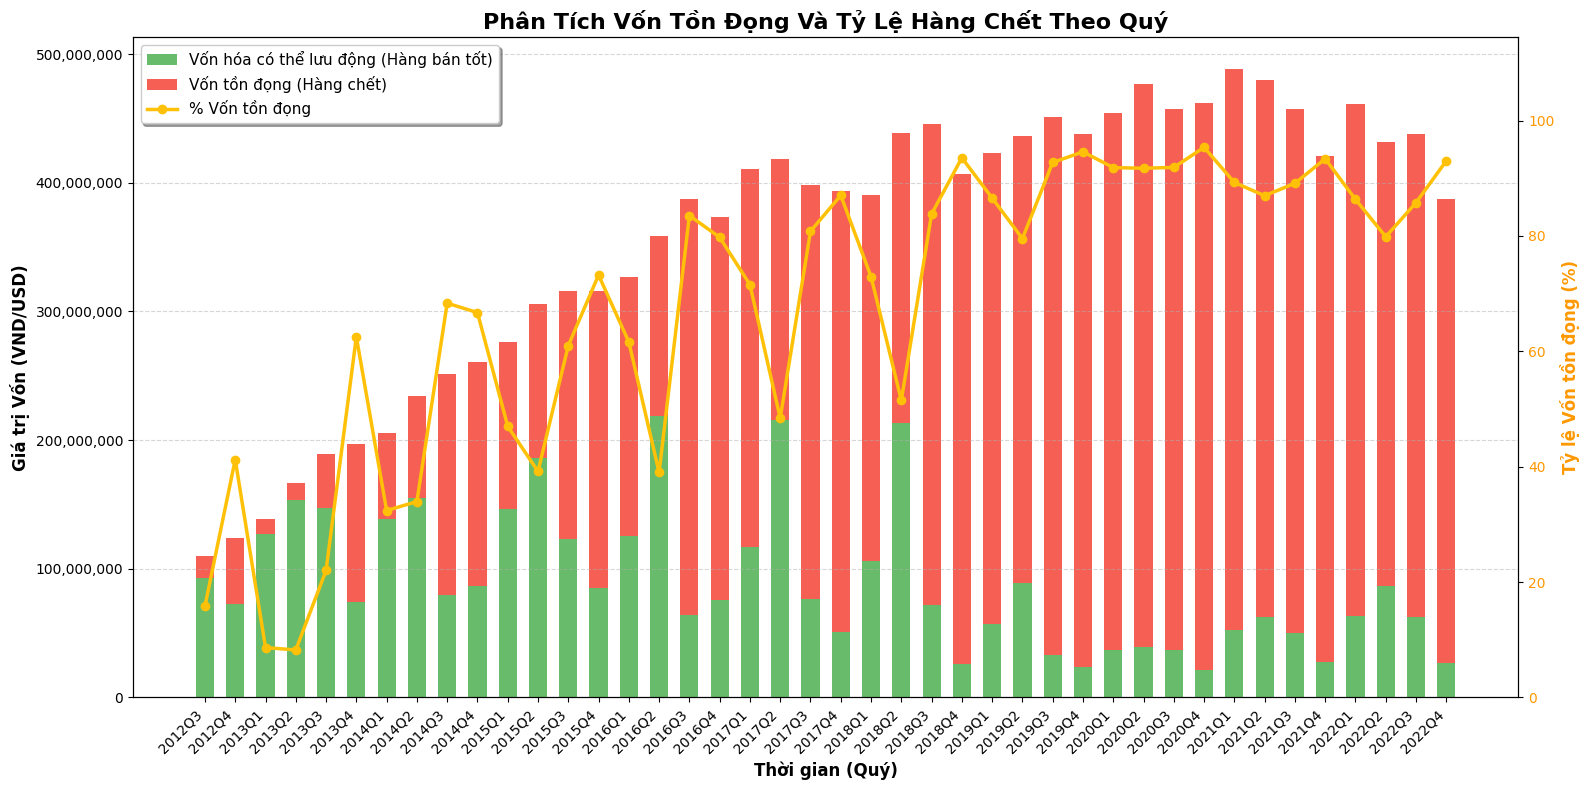

In [ ]:
# Chuyển đổi định dạng ngày tháng
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Tạo cột Quý (Năm-Quý, ví dụ: 2022Q1, 2022Q2)
inventory['Quarter'] = inventory['snapshot_date'].dt.to_period('Q')

# ---------------------------------------------------------
# LƯU Ý NGHIỆP VỤ: Lấy mốc thời gian "Chốt sổ" (End of Quarter)
# Lấy ra ngày chụp tồn kho cuối cùng của mỗi quý để làm đại diện cho Quý đó
# ---------------------------------------------------------
end_of_quarter_dates = inventory.groupby('Quarter')['snapshot_date'].max()
quarterly_inventory = inventory[inventory['snapshot_date'].isin(end_of_quarter_dates)].copy()

# 2. GHÉP BẢNG ĐỂ TÍNH TIỀN VỐN
df = pd.merge(quarterly_inventory, products[['product_id', 'cogs']], on='product_id', how='left')

# Tính tổng vốn cho TỪNG sản phẩm
df['total_capital'] = df['stock_on_hand'] * df['cogs']

# 3. PHÂN LOẠI VỐN
# Cờ quá tải = 1 VÀ tỷ lệ bán ra < 10% (Bạn có thể tinh chỉnh 0.1)
df['is_dead_stock'] = (df['overstock_flag'] == 1) & (df['sell_through_rate'] < 0.1)
df['dead_stock_capital'] = df.apply(lambda x: x['total_capital'] if x['is_dead_stock'] else 0, axis=1)

# 4. GOM NHÓM THEO QUÝ
quarterly_capital = df.groupby('Quarter').agg(
    Total_Inventory_Capital=('total_capital', 'sum'),
    Dead_Stock_Capital=('dead_stock_capital', 'sum')
).reset_index()

# Chuyển Quarter về chuỗi (String) để biểu đồ đọc được dễ dàng
quarterly_capital['Quarter_Str'] = quarterly_capital['Quarter'].astype(str)

# Vốn hóa lưu động (Vốn hiệu quả) = Tổng vốn - Vốn tồn đọng
quarterly_capital['Active_Working_Capital'] = quarterly_capital['Total_Inventory_Capital'] - quarterly_capital['Dead_Stock_Capital']

# Tính phần trăm (%) Vốn tồn đọng trên tổng vốn
quarterly_capital['Pct_Dead_Stock'] = (quarterly_capital['Dead_Stock_Capital'] / quarterly_capital['Total_Inventory_Capital']) * 100

# 5. VẼ BIỂU ĐỒ TRỰC QUAN HOÁ
fig, ax1 = plt.subplots(figsize=(16, 8))

# Trục Y thứ 1: Cột chồng
ax1.bar(quarterly_capital['Quarter_Str'], quarterly_capital['Active_Working_Capital'], 
        label='Vốn hóa có thể lưu động (Hàng bán tốt)', color='#4CAF50', width=0.6, alpha=0.85)

ax1.bar(quarterly_capital['Quarter_Str'], quarterly_capital['Dead_Stock_Capital'], 
        bottom=quarterly_capital['Active_Working_Capital'], 
        label='Vốn tồn đọng (Hàng chết)', color='#F44336', width=0.6, alpha=0.85)

ax1.set_xlabel('Thời gian (Quý)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Giá trị Vốn (VND/USD)', fontsize=12, fontweight='bold')
ax1.set_title('Phân Tích Vốn Tồn Đọng Và Tỷ Lệ Hàng Chết Theo Quý', fontsize=16, fontweight='bold')

# Định dạng số hàng nghìn và xoay nhãn trục X để không bị đè lên nhau
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=45, ha='right')

# Trục Y thứ 2: Đường phần trăm
ax2 = ax1.twinx()
ax2.plot(quarterly_capital['Quarter_Str'], quarterly_capital['Pct_Dead_Stock'], 
         color='#FFC107', marker='o', linewidth=2.5, markersize=6, 
         label='% Vốn tồn đọng')

ax2.set_ylabel('Tỷ lệ Vốn tồn đọng (%)', fontsize=12, fontweight='bold', color='#FF9800')
ax2.tick_params(axis='y', labelcolor='#FF9800')
# Chống lỗi nếu tập data bị trống, giới hạn trục y từ 0 đến max + 20% đệm
max_pct = quarterly_capital['Pct_Dead_Stock'].max()
ax2.set_ylim(0, (max_pct * 1.2) if pd.notna(max_pct) and max_pct > 0 else 100)

# Gom chú thích (Legend)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, frameon=True, shadow=True)

# Lưới (grid)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Màu xanh lá cây: Bất cứ sản phẩm nào không chạm ngưỡng báo động đỏ

Màu đỏ: Là tổng giá trị vốn (stock_on_hand * cogs) của những sản phẩm bị dán cờ dư thừa (overstock_flag = 1) VÀ có tỷ lệ bán ra cực thấp (sell_through_rate < 0.1)

Màu vàng: (Vốn màu Đỏ / Tổng vốn Xanh + Đỏ) * 100

Tổng giá trị tồn kho (cột Xanh + Đỏ) đã tăng phi mã gấp gần 5 lần, từ mức ~100 triệu (năm 2012) lên đỉnh điểm gần 500 triệu vào giai đoạn 2020-2022

Sự tăng trưởng quy mô đi kèm với sự suy giảm nghiêm trọng về chất lượng dòng tiền. Tỷ lệ % Vốn tồn đọng (đường màu vàng) leo dốc từ mức an toàn dưới 20% (năm 2013) lên đến ngưỡng khủng hoảng 80% - 95% trong giai đoạn 2020-2022.

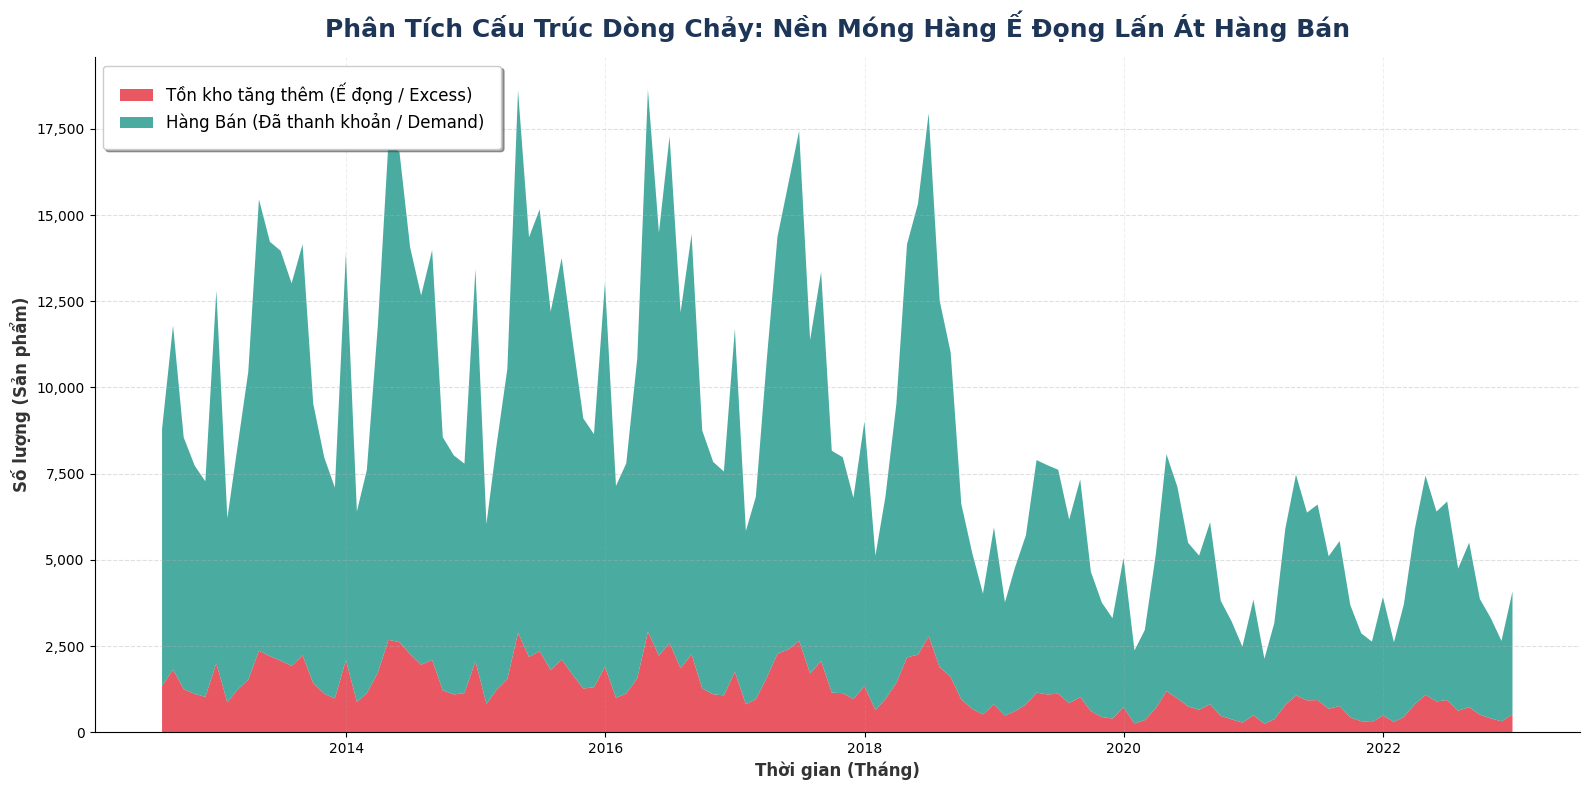

In [ ]:
## GỘP CHUNG VỚI GROSS MARGIN hoặc tách ra thành 1 phần tổng thể trước khi vào phần đó

inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# 2. GOM NHÓM DỮ LIỆU THEO THÁNG
monthly_flow = inventory.groupby('snapshot_date').agg(
    Total_Received=('units_received', 'sum'),
    Total_Sold=('units_sold', 'sum')
).reset_index()

# Tính Tồn kho tăng thêm (Net Addition) = Nhập - Bán
monthly_flow['Net_Addition'] = monthly_flow['Total_Received'] - monthly_flow['Total_Sold']

# Sắp xếp theo thời gian
monthly_flow = monthly_flow.sort_values('snapshot_date')

# 3. VẼ BIỂU ĐỒ MIỀN CHỒNG (STACKED AREA CHART)
fig, ax = plt.subplots(figsize=(16, 8))

# ĐỔI THỨ TỰ: Cho Net_Addition (Ế đọng) xuống lớp dưới cùng, Total_Sold (Bán được) lên trên
# ĐỔI MÀU: Sử dụng bảng màu chuyên nghiệp (Crimson Red cho lỗi/ế, Teal Green cho phần bán tốt)
ax.stackplot(monthly_flow['snapshot_date'], 
             monthly_flow['Net_Addition'],   # Lớp đáy (Đỏ)
             monthly_flow['Total_Sold'],     # Lớp trên (Xanh)
             labels=['Tồn kho tăng thêm (Ế đọng / Excess)', 'Hàng Bán (Đã thanh khoản / Demand)'],
             colors=['#E63946', '#2A9D8F'],  # Mã màu hiện đại, đỡ chói hơn
             alpha=0.85)                     # Độ trong suốt dịu mắt

# Định dạng Trục Y và Tiêu đề
ax.set_xlabel('Thời gian (Tháng)', fontsize=12, fontweight='bold', color='#333333')
ax.set_ylabel('Số lượng (Sản phẩm)', fontsize=12, fontweight='bold', color='#333333')
ax.set_title('Phân Tích Cấu Trúc Dòng Chảy: Nền Móng Hàng Ế Đọng Lấn Át Hàng Bán', 
             fontsize=18, fontweight='bold', color='#1D3557', pad=15)

# Định dạng số cho trục Y (thêm dấu phẩy)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Tùy chỉnh chú thích (Legend)
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True, borderpad=1)

# Lưới (grid) tinh tế hơn
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle='--', alpha=0.2)

# Xóa viền trên và viền phải của biểu đồ cho thoáng
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Lượng nhập hàng dư thừa của segment

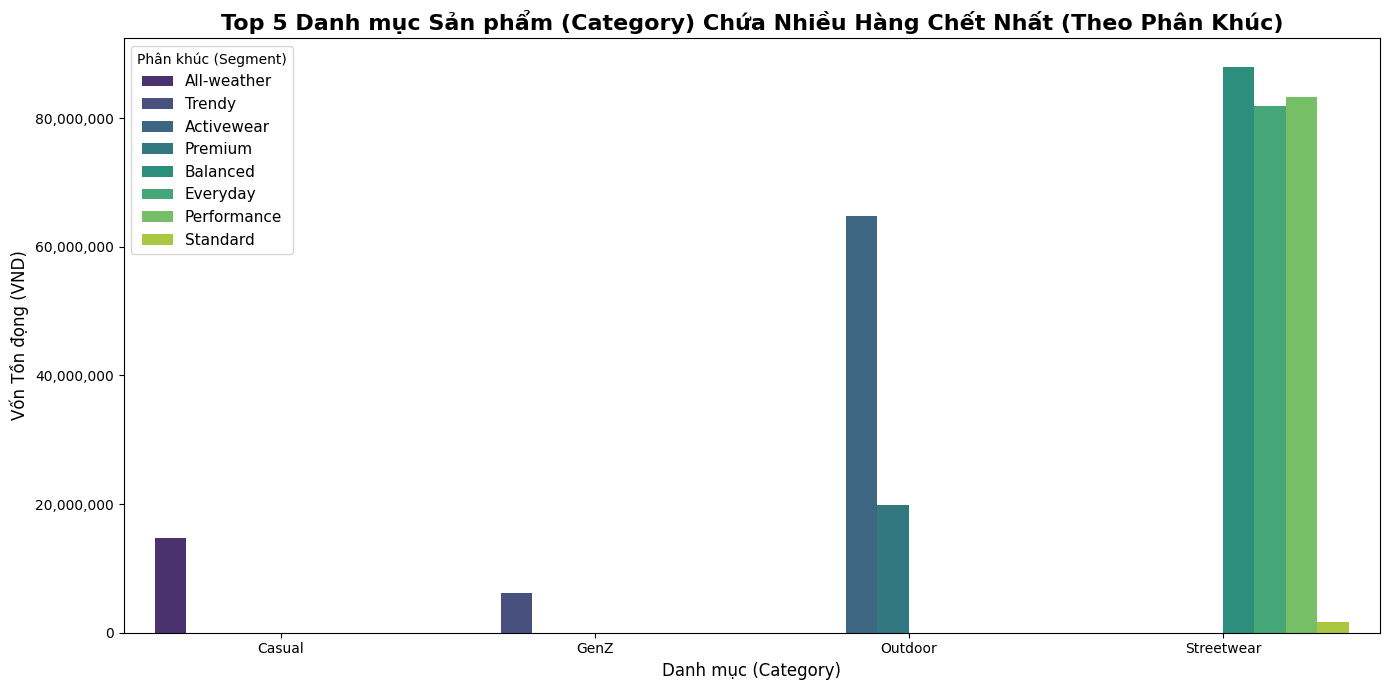

Danh mục bị ứ đọng nghiêm trọng nhất là: Streetwear


In [ ]:
## Gộp chung vào gross margin luôn

# 1. TÍNH TOÁN VỐN ĐỌNG THEO CATEGORY VÀ SEGMENT
cat_seg_capital = dead_stock_df.groupby(['category', 'segment'])['capital'].sum().reset_index()

# Lọc ra Top 5 Danh mục chiếm nhiều vốn đọng nhất để dễ nhìn
top_categories = cat_seg_capital.groupby('category')['capital'].sum().nlargest(5).index
filtered_data = cat_seg_capital[cat_seg_capital['category'].isin(top_categories)]

# 2. VẼ BIỂU ĐỒ CỘT NHÓM (GROUPED BAR CHART)
plt.figure(figsize=(14, 7))
sns.barplot(data=filtered_data, x='category', y='capital', hue='segment', palette='viridis')

plt.title('Top 5 Danh mục Sản phẩm (Category) Chứa Nhiều Hàng Chết Nhất (Theo Phân Khúc)', fontsize=16, fontweight='bold')
plt.xlabel('Danh mục (Category)', fontsize=12)
plt.ylabel('Vốn Tồn đọng (VND)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.legend(title='Phân khúc (Segment)', fontsize=11)

plt.tight_layout()
plt.show()

# Xác định danh mục tệ nhất để dùng cho Phần 3
worst_category = top_categories[0]
print(f"Danh mục bị ứ đọng nghiêm trọng nhất là: {worst_category}")

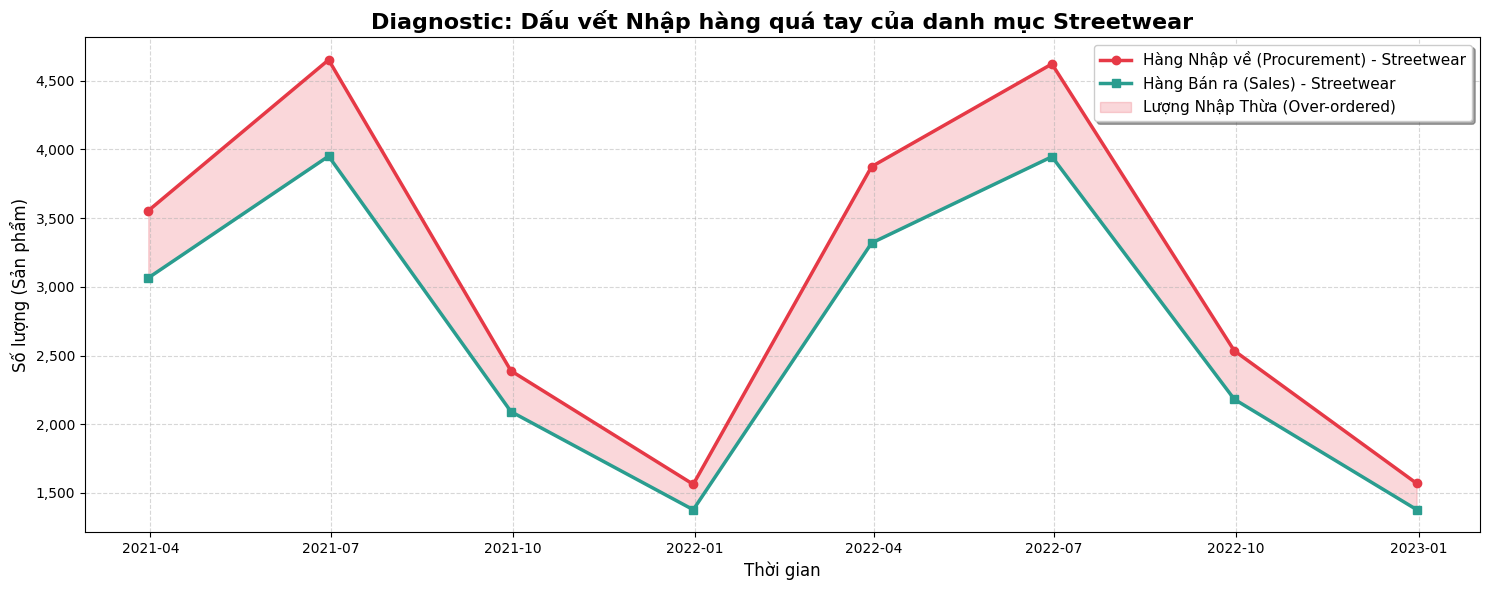

In [ ]:
## HAY
# 1. LỌC LỊCH SỬ CỦA DANH MỤC TỆ NHẤT
# Sử dụng biến worst_category từ phần 2 (ví dụ: 'Outerwear' hoặc 'T-shirt')
# Để biểu đồ dễ đọc, ta chỉ xét lịch sử trong năm 2021 và 2022
history_df = df[(df['category'] == worst_category) & (df['snapshot_date'].dt.year >= 2021)].copy()

# Gom nhóm theo tháng để xem tổng cung cầu của danh mục này
monthly_trend = history_df.groupby('snapshot_date').agg(
    Units_Received=('units_received', 'sum'),
    Units_Sold=('units_sold', 'sum')
).reset_index()

# 2. VẼ BIỂU ĐỒ TRUY VẾT MUA HÀNG VS. SỨC MUA THỰC TẾ
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(monthly_trend['snapshot_date'], monthly_trend['Units_Received'], 
        label=f'Hàng Nhập về (Procurement) - {worst_category}', 
        color='#E63946', marker='o', linewidth=2.5)

ax.plot(monthly_trend['snapshot_date'], monthly_trend['Units_Sold'], 
        label=f'Hàng Bán ra (Sales) - {worst_category}', 
        color='#2A9D8F', marker='s', linewidth=2.5)

# Đổ màu phần chênh lệch (Lượng nhập thừa)
ax.fill_between(monthly_trend['snapshot_date'], 
                monthly_trend['Units_Sold'], 
                monthly_trend['Units_Received'], 
                where=(monthly_trend['Units_Received'] > monthly_trend['Units_Sold']), 
                interpolate=True, color='#E63946', alpha=0.2, label='Lượng Nhập Thừa (Over-ordered)')

ax.set_title(f'Diagnostic: Dấu vết Nhập hàng quá tay của danh mục {worst_category}', fontsize=16, fontweight='bold')
ax.set_xlabel('Thời gian', fontsize=12)
ax.set_ylabel('Số lượng (Sản phẩm)', fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

ax.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
ax.grid(axis='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---

### Rủi ro tài chính không thoát được hàng tồn

--------------------------------------------------
🎯 BÁO CÁO THIỆT HẠI DỰ KIẾN NĂM 2023 🎯
Tổng vốn tồn kho hiện tại: 387,629,923 VND
Giá trị bốc hơi do Lão hóa: 315,525,893 VND
Số lượng sản phẩm chiếm chỗ vô ích: 96,941 đơn vị
--------------------------------------------------
Biên lợi nhuận gộp ban đầu (Kỳ vọng): 17.63%
Biên lợi nhuận gộp ĐIỀU CHỈNH (Thực tế): -49.42%
=> Thiệt hại Margin: 67.05%
--------------------------------------------------


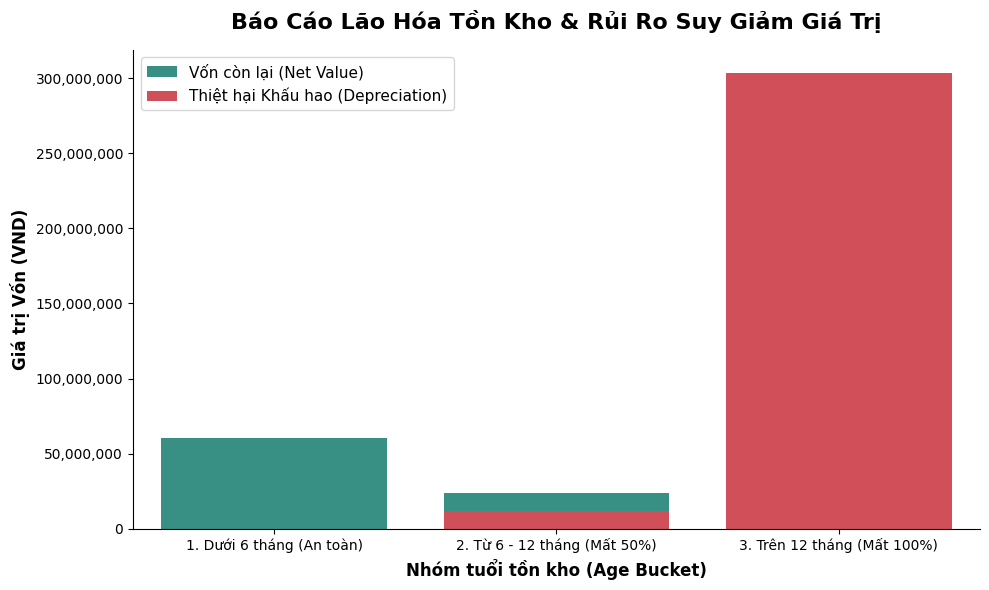

In [ ]:
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# 2. TÍNH TUỔI TỒN KHO (INVENTORY AGING)
# Giả định proxy: Đếm số tháng một sản phẩm nằm trong tình trạng bán chậm (sell_through_rate < 0.1)
stagnant_inventory = inventory[(inventory['sell_through_rate'] < 0.1) & 
                                (inventory['stock_on_hand'] > 0)].copy()

age_df = stagnant_inventory.groupby('product_id')['snapshot_date'].nunique().reset_index()
age_df.rename(columns={'snapshot_date': 'age_in_months'}, inplace=True)

# 3. CHUẨN BỊ DỮ LIỆU THÁNG MỚI NHẤT ĐỂ ĐÁNH GIÁ (VD: Tháng 12/2022)
latest_date = inventory['snapshot_date'].max()
latest_inventory = inventory[inventory['snapshot_date'] == latest_date].copy()

# Ghép tuổi tồn kho vào (nếu không có trong age_df tức là hàng mới, tuổi = 0)
latest_inventory = pd.merge(latest_inventory, age_df, on='product_id', how='left')
latest_inventory['age_in_months'] = latest_inventory['age_in_months'].fillna(0)

# Ghép cogs và price để tính tiền
latest_inventory = pd.merge(latest_inventory, products[['product_id', 'cogs', 'price']], on='product_id', how='left')
latest_inventory['capital'] = latest_inventory['stock_on_hand'] * latest_inventory['cogs']

# 4. ÁP DỤNG LUẬT KHẤU HAO (DEPRECIATION ASSUMPTION)
def calculate_depreciation(row):
    if row['age_in_months'] >= 12:
        return row['capital'] * 1.0  # Mất trắng 100% (Write-off)
    elif row['age_in_months'] >= 6:
        return row['capital'] * 0.5  # Mất 50% giá trị
    else:
        return 0  # Dưới 6 tháng coi như an toàn

latest_inventory['depreciation_loss'] = latest_inventory.apply(calculate_depreciation, axis=1)

# Phân nhóm để vẽ biểu đồ
def age_bucket(months):
    if months >= 12: return '3. Trên 12 tháng (Mất 100%)'
    elif months >= 6: return '2. Từ 6 - 12 tháng (Mất 50%)'
    else: return '1. Dưới 6 tháng (An toàn)'

latest_inventory['age_bucket'] = latest_inventory['age_in_months'].apply(age_bucket)

# 5. KHÁI TOÁN THIỆT HẠI VÀ BIÊN LỢI NHUẬN GỘP
total_capital = latest_inventory['capital'].sum()
total_loss = latest_inventory['depreciation_loss'].sum()
wasted_space_units = latest_inventory[latest_inventory['age_in_months'] >= 6]['stock_on_hand'].sum()

# Giả lập Biên lợi nhuận Gộp (Gross Margin) nếu bán hết đống hàng này
expected_revenue = (latest_inventory['stock_on_hand'] * latest_inventory['price']).sum()
original_gross_profit = expected_revenue - total_capital
original_margin = (original_gross_profit / expected_revenue) * 100

adjusted_gross_profit = original_gross_profit - total_loss
adjusted_margin = (adjusted_gross_profit / expected_revenue) * 100

print("-" * 50)
print("🎯 BÁO CÁO THIỆT HẠI DỰ KIẾN NĂM 2023 🎯")
print(f"Tổng vốn tồn kho hiện tại: {total_capital:,.0f} VND")
print(f"Giá trị bốc hơi do Lão hóa: {total_loss:,.0f} VND")
print(f"Số lượng sản phẩm chiếm chỗ vô ích: {wasted_space_units:,.0f} đơn vị")
print("-" * 50)
print(f"Biên lợi nhuận gộp ban đầu (Kỳ vọng): {original_margin:.2f}%")
print(f"Biên lợi nhuận gộp ĐIỀU CHỈNH (Thực tế): {adjusted_margin:.2f}%")
print(f"=> Thiệt hại Margin: {(original_margin - adjusted_margin):.2f}%")
print("-" * 50)

# 6. VẼ BIỂU ĐỒ TRỰC QUAN HÓA
aging_summary = latest_inventory.groupby('age_bucket').agg(
    Capital=('capital', 'sum'),
    Loss=('depreciation_loss', 'sum')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

# Vẽ cột chồng: Vốn (Màu xanh) nằm dưới, Phần mất đi (Màu đỏ) nằm đè lên
sns.barplot(data=aging_summary, x='age_bucket', y='Capital', color='#2A9D8F', label='Vốn còn lại (Net Value)')
sns.barplot(data=aging_summary, x='age_bucket', y='Loss', color='#E63946', label='Thiệt hại Khấu hao (Depreciation)')

ax.set_title('Báo Cáo Lão Hóa Tồn Kho & Rủi Ro Suy Giảm Giá Trị', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Nhóm tuổi tồn kho (Age Bucket)', fontsize=12, fontweight='bold')
ax.set_ylabel('Giá trị Vốn (VND)', fontsize=12, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Xóa viền trên và phải
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# Load inventory data
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Aggregate inventory by month (total stock on hand across all products)
inventory_monthly = inventory.groupby('snapshot_date').agg({
    'stock_on_hand': 'sum',
    'units_sold': 'sum',
    'units_received': 'sum'
}).reset_index()

# Line graph for inventory over time
fig = px.line(
    inventory_monthly, 
    x='snapshot_date', 
    y='stock_on_hand',
    title='Inventory (Stock on Hand) Over Time',
    labels={'snapshot_date': 'Date', 'stock_on_hand': 'Stock on Hand'},
    markers=True
)
fig.update_layout(template='plotly_white')
fig.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20948\3562599422.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=size_capital, x='size', y='capital', ax=axes[0], palette='Reds_r')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20948\3562599422.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=color_capital, x='capital', y='color', ax=axes[1], palette='Oranges_r')


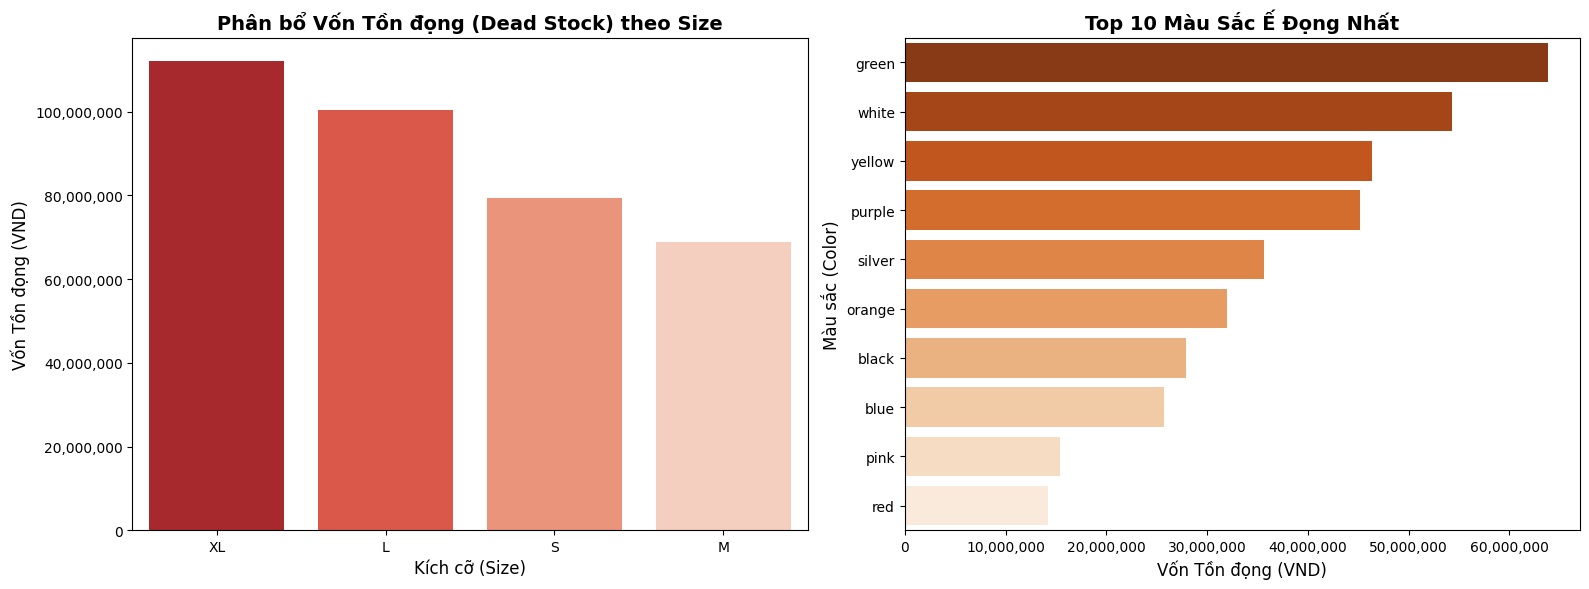

In [ ]:
# Màu và size bị ế

inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Ghép bảng để lấy thêm thông tin Size, Color, COGS từ products
df = pd.merge(inventory, products[['product_id', 'size', 'color', 'cogs']], on='product_id', how='left')
df['capital'] = df['stock_on_hand'] * df['cogs']

# 2. LỌC DỮ LIỆU THÁNG MỚI NHẤT & XÁC ĐỊNH DEAD STOCK
latest_date = df['snapshot_date'].max()
latest_month_df = df[df['snapshot_date'] == latest_date].copy()

# Định nghĩa Dead Stock: cờ overstock = 1 và bán ra dưới 10%
dead_stock_df = latest_month_df[(latest_month_df['overstock_flag'] == 1) & 
                                (latest_month_df['sell_through_rate'] < 0.1)]

# 3. PHÂN TÍCH THEO SIZE VÀ COLOR
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Vốn đọng theo Size
size_capital = dead_stock_df.groupby('size')['capital'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=size_capital, x='size', y='capital', ax=axes[0], palette='Reds_r')
axes[0].set_title('Phân bổ Vốn Tồn đọng (Dead Stock) theo Size', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kích cỡ (Size)', fontsize=12)
axes[0].set_ylabel('Vốn Tồn đọng (VND)', fontsize=12)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Biểu đồ 2: Vốn đọng theo Color (Top 10 màu tệ nhất)
color_capital = dead_stock_df.groupby('color')['capital'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(data=color_capital, x='capital', y='color', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 10 Màu Sắc Ế Đọng Nhất', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Vốn Tồn đọng (VND)', fontsize=12)
axes[1].set_ylabel('Màu sắc (Color)', fontsize=12)
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

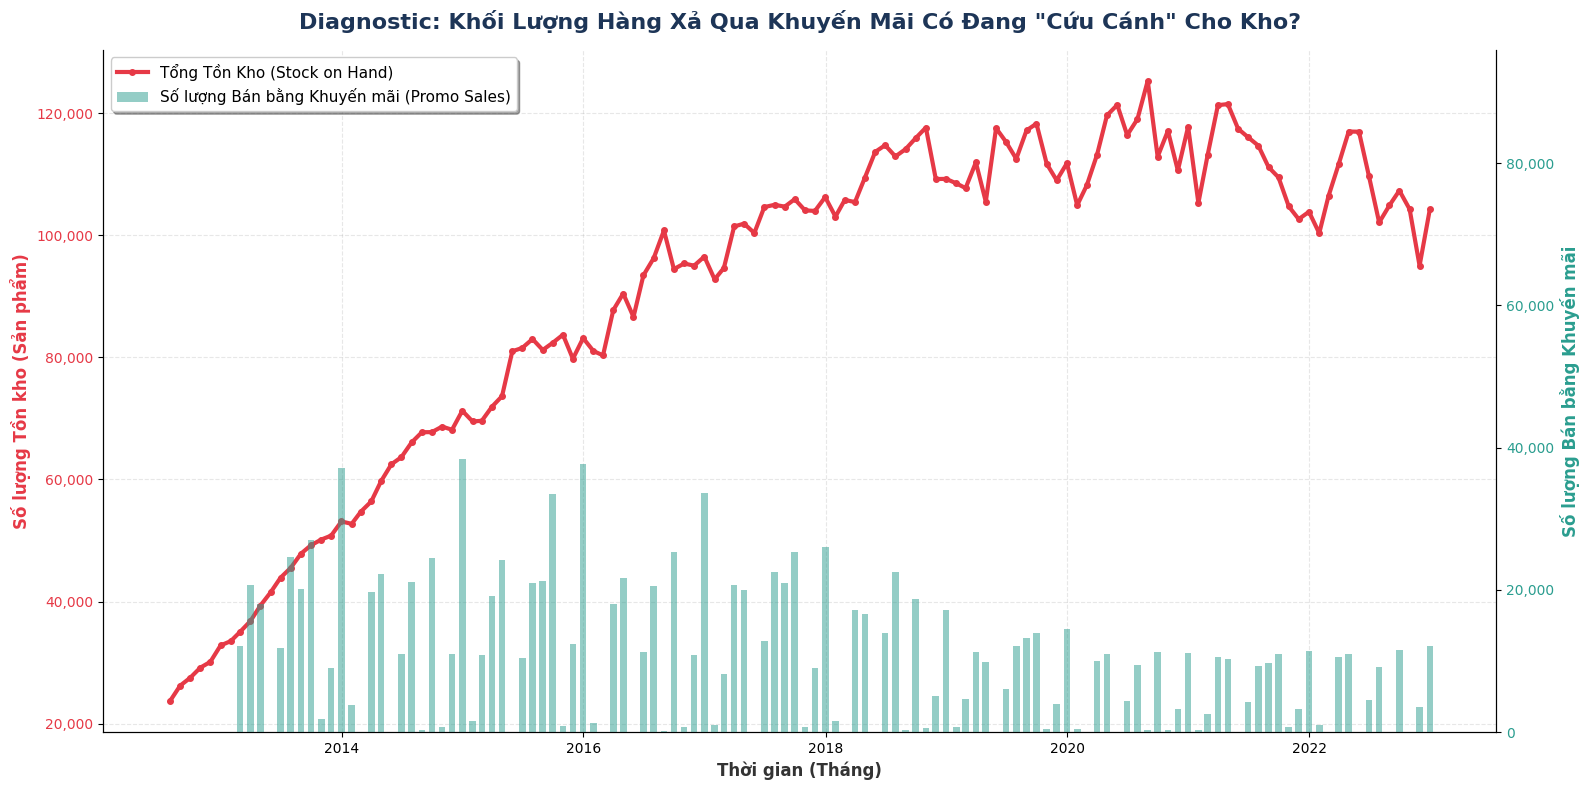

In [ ]:
# KHỐI LƯƠNG XẢ HÀNG QUA KHUYẾN MÃI

# 2. XỬ LÝ DỮ LIỆU BÁN HÀNG VÀ KHUYẾN MÃI
orders['order_date'] = pd.to_datetime(orders['order_date'])
# Đưa order_date về ngày cuối tháng để merge với snapshot_date của inventory
orders['month_end'] = orders['order_date'] + pd.offsets.MonthEnd(0)

# Merge chi tiết đơn hàng với thông tin đơn hàng
sales_df = pd.merge(order_items, orders[['order_id', 'month_end']], on='order_id', how='left')

# Xác định xem một sản phẩm được bán ra có dùng mã khuyến mãi hay không
sales_df['is_promo'] = sales_df['promo_id'].notna()

# Tính tổng số lượng bán bằng khuyến mãi theo từng tháng
monthly_sales = sales_df.groupby('month_end').agg(
    Promo_Sold_Qty=('quantity', lambda x: x[sales_df.loc[x.index, 'is_promo']].sum())
).reset_index()

# 3. XỬ LÝ DỮ LIỆU TỒN KHO
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])
monthly_inventory = inventory.groupby('snapshot_date').agg(
    Total_Stock_On_Hand=('stock_on_hand', 'sum')
).reset_index()

# 4. MERGE DỮ LIỆU KHO VÀ KHUYẾN MÃI
combined_df = pd.merge(monthly_inventory, monthly_sales, left_on='snapshot_date', right_on='month_end', how='inner')

# 5. VẼ BIỂU ĐỒ TRỰC QUAN HÓA (DUAL-AXIS CHART NHƯNG CÙNG ĐƠN VỊ SỐ LƯỢNG)
fig, ax1 = plt.subplots(figsize=(16, 8))

# Trục Y thứ 1: Tổng tồn kho (Đường màu đỏ)
ax1.plot(combined_df['snapshot_date'], combined_df['Total_Stock_On_Hand'], 
         color='#E63946', linewidth=3, marker='o', markersize=4, label='Tổng Tồn Kho (Stock on Hand)')

ax1.set_xlabel('Thời gian (Tháng)', fontsize=12, fontweight='bold', color='#333333')
ax1.set_ylabel('Số lượng Tồn kho (Sản phẩm)', fontsize=12, fontweight='bold', color='#E63946')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.tick_params(axis='y', labelcolor='#E63946')

# Trục Y thứ 2: Số lượng bán bằng Khuyến mãi (Biểu đồ cột mờ phía dưới)
ax2 = ax1.twinx()
ax2.bar(combined_df['snapshot_date'], combined_df['Promo_Sold_Qty'], 
        width=20, color='#2A9D8F', alpha=0.5, label='Số lượng Bán bằng Khuyến mãi (Promo Sales)')

ax2.set_ylabel('Số lượng Bán bằng Khuyến mãi', fontsize=12, fontweight='bold', color='#2A9D8F')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax2.tick_params(axis='y', labelcolor='#2A9D8F')

# Mẹo hiển thị: Đẩy giới hạn trục Y2 lên gấp đôi max để cột mờ không đè lên đường line phía trên
ax2.set_ylim(0, max(combined_df['Promo_Sold_Qty']) * 2.5) 

# Tiêu đề và Legend
plt.title('Diagnostic: Khối Lượng Hàng Xả Qua Khuyến Mãi Có Đang "Cứu Cánh" Cho Kho?', 
          fontsize=16, fontweight='bold', color='#1D3557', pad=15)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=11, frameon=True, shadow=True)

ax1.grid(axis='both', linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

[<BarContainer object of 126 artists>,
 <BarContainer object of 126 artists>,
 <BarContainer object of 126 artists>]

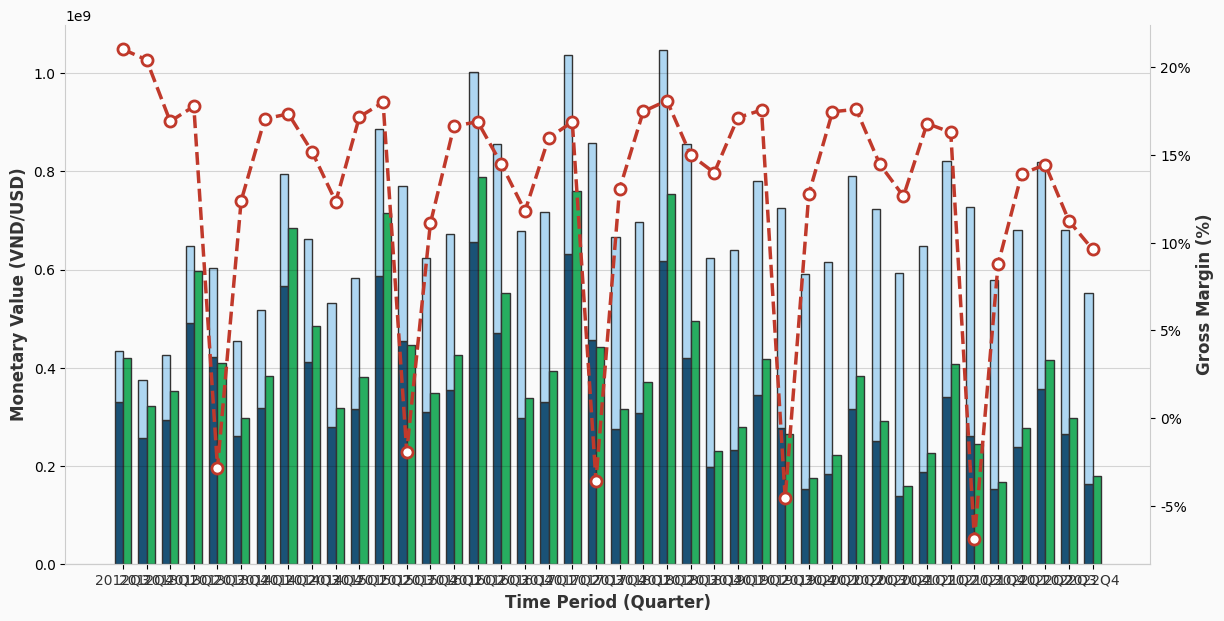

In [ ]:

# 2. XỬ LÝ DỮ LIỆU THEO QUÝ (Quarter)
# 2.1. Doanh thu và COGS (Cộng dồn theo quý)
sales['Date'] = pd.to_datetime(sales['Date'])
sales['year_quarter'] = sales['Date'].dt.to_period('Q')
quarterly_sales = sales.groupby('year_quarter')[['Revenue', 'COGS']].sum().reset_index()

# 2.2. Vốn tồn kho (Tính tổng từng tháng, sau đó lấy trung bình quý)
inventory_merged = pd.merge(inventory, products[['product_id', 'cogs']], on='product_id', how='left')
inventory_merged['unsold_capital'] = inventory_merged['stock_on_hand'] * inventory_merged['cogs']

# Tạo cột ngày để xác định quý
inventory_merged['date'] = pd.to_datetime(
    inventory_merged['year'].astype(str) + '-' + inventory_merged['month'].astype(str) + '-01'
)
# Tính tổng vốn tồn đọng của tất cả sản phẩm trong từng tháng riêng biệt
monthly_inventory = inventory_merged.groupby('date')['unsold_capital'].sum().reset_index()
monthly_inventory['year_quarter'] = monthly_inventory['date'].dt.to_period('Q')

# Lấy trung bình lượng vốn tồn đọng trong các tháng của quý đó
quarterly_inventory = monthly_inventory.groupby('year_quarter')['unsold_capital'].mean().reset_index()

# 2.3. Tổng hợp và tính biên lợi nhuận
financial_summary = pd.merge(quarterly_sales, quarterly_inventory, on='year_quarter', how='inner')
financial_summary['gross_margin'] = ((financial_summary['Revenue'] - financial_summary['COGS']) / financial_summary['Revenue']) * 100
financial_summary['time_period'] = financial_summary['year_quarter'].astype(str)

# 3. VẼ BIỂU ĐỒ
fig, ax1 = plt.subplots(figsize=(14, 7), facecolor='#FAFAFA')
ax1.set_facecolor('#FAFAFA')

x_indexes = np.arange(len(financial_summary['time_period']))
bar_width = 0.35 

# Trục trái: Các cột giá trị 
bar_cogs = ax1.bar(
    x_indexes - bar_width/2, 
    financial_summary['COGS'], 
    bar_width, 
    label='COGS (Capital of Sold Goods)', 
    color='#1A5276', # Xanh biển đậm
    edgecolor='#333333',
    linewidth=1
)

bar_unsold = ax1.bar(
    x_indexes - bar_width/2, 
    financial_summary['unsold_capital'], 
    bar_width, 
    bottom=financial_summary['COGS'], 
    label='Unsold Inventory Capital (Quarterly Avg)', 
    color='#AED6F1', # Xanh nhạt
    edgecolor='#333333', 
    linewidth=1
)

bar_revenue = ax1.bar(
    x_indexes + bar_width/2, 
    financial_summary['Revenue'], 
    bar_width, 
    label='Revenue', 
    color='#27AE60', # Xanh lá cây
    edgecolor='#333333',
    linewidth=1
)

# Cấu hình trục X & Y trái
ax1.set_xlabel('Time Period (Quarter)', fontweight='bold', fontsize=12, color='#333333')
ax1.set_ylabel('Monetary Value (VND/USD)', fontweight='bold', fontsize=12, color='#333333')
ax1.set_xticks(x_indexes)
ax1.set_xticklabels(financial_summary['time_period'], rotation=0, color='#333333') # Nhãn quý ngắn gọn nên để ngang (0 độ)

ax1.grid(axis='y', linestyle='-', alpha=0.15, color='#000000')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#CCCCCC')
ax1.spines['bottom'].set_color('#CCCCCC')

# Trục phải: Biên lợi nhuận gộp (%)
ax2 = ax1.twinx()
line_margin = ax2.plot(
    x_indexes, 
    financial_summary['gross_margin'], 
    label='Gross Margin (%)', 
    color='#C0392B',   # Màu đỏ
    linestyle='--',    # Nét đứt
    linewidth=2.5, 
    marker='o',     
    markersize=8, 
    markerfacecolor='#FFFFFF', 
    markeredgecolor='#C0392B',
    markeredgewidth=2
)

# Cấu hình trục Y phải
ax2.set_ylabel('Gross Margin (%)', fontweight='bold', fontsize=12, color='#333333')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_color('#CCCCCC')
ax2.spines['bottom'].set_color('#CCCCCC')

# Cấu hình Legend 
handles_ax1

In [ ]:

if sales is not None:
    sales["Year"] = pd.to_datetime(sales["Date"]).dt.year
    annual = (
        sales.groupby("Year")[["Revenue", "COGS"]]
        .sum()
        .reset_index()
    )
else:
    # ── Dữ liệu mẫu nếu chưa có file ──
    print("[INFO] Không tìm thấy sales.csv — dùng dữ liệu mẫu minh hoạ.")
    annual = pd.DataFrame({
        "Year":    [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
        "Revenue": [1.20, 2.80, 4.50, 6.30, 7.80, 9.10, 10.5, 12.3, 11.8, 14.2, 16.5],
        "COGS":    [0.80, 1.85, 2.95, 4.10, 5.00, 5.80,  6.7,  7.8,  7.5,  9.0, 10.4],
    })
    # đơn vị: triệu VND (mẫu)

# Unsold Inventory Capital = tổng (stock_on_hand × price) cuối năm, nhóm theo year
if inv is not None:
    inv["Year"] = pd.to_datetime(inv["snapshot_date"]).dt.year
    # lấy snapshot cuối năm (tháng 12)
    inv_dec = inv[inv_raw["month"] == 12] if "month" in inv_raw.columns else inv_raw
    # nếu inventory.csv có cột price thì tính; nếu không, proxy = units_sold * 0.3 (hàng tồn ~ 30% bán ra)
    if "price" in inv_raw.columns:
        inv_dec = inv_dec.copy()
        inv_dec["unsold_cap"] = inv_dec["stock_on_hand"] * inv_dec["price"]
    else:
        inv_dec = inv_dec.copy()
        inv_dec["unsold_cap"] = inv_dec["stock_on_hand"] * (inv_dec.get("unit_price", 1))
    unsold = inv_dec.groupby("Year")["unsold_cap"].sum().reset_index()
    unsold.columns = ["Year", "UnsoldCap"]
    annual = annual.merge(unsold, on="Year", how="left")
    annual["UnsoldCap"] = annual["UnsoldCap"].fillna(0)
else:
    # proxy: tồn kho ≈ 15–25% COGS mỗi năm (minh hoạ)
    rng = np.random.default_rng(42)
    annual["UnsoldCap"] = annual["COGS"] * rng.uniform(0.15, 0.25, len(annual))

# Gross Margin (%)
annual["GrossMargin"] = (annual["Revenue"] - annual["COGS"]) / annual["Revenue"] * 100

years = annual["Year"].values
n     = len(years)

# ─────────────────────────────────────────────────────────────
# 3. VẼ BIỂU ĐỒ
# ─────────────────────────────────────────────────────────────
FIG_W, FIG_H = 14, 7
BAR_GROUP = 0.55          # tổng độ rộng 1 nhóm
W         = BAR_GROUP / 2  # độ rộng mỗi cột

# Màu
C_COGS    = "#1565C0"   # xanh dương đậm — COGS
C_UNSOLD  = "#90CAF9"   # xanh dương nhạt — Unsold Inventory
C_REV     = "#2E7D32"   # xanh lá  — Revenue
C_MARGIN  = "#E65100"   # cam đậm  — Gross Margin line
C_GRID    = "#E0E0E0"
BG        = "#FAFAFA"

fig, ax1 = plt.subplots(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor(BG)
ax1.set_facecolor(BG)
ax2 = ax1.twinx()

x = np.arange(n)

# ── Cột 1: Stacked (COGS + UnsoldCap) ──
pos1 = x - W / 2
bars_cogs = ax1.bar(
    pos1, annual["COGS"], width=W,
    color=C_COGS, label="COGS", zorder=3
)
bars_unsold = ax1.bar(
    pos1, annual["UnsoldCap"], width=W,
    bottom=annual["COGS"],
    color=C_UNSOLD, label="Unsold Inventory Capital", zorder=3
)

# ── Cột 2: Revenue ──
pos2 = x + W / 2
bars_rev = ax1.bar(
    pos2, annual["Revenue"], width=W,
    color=C_REV, alpha=0.88, label="Revenue", zorder=3
)

# ── Đường Gross Margin (trục phụ) ──
line_gm, = ax2.plot(
    x, annual["GrossMargin"],
    color=C_MARGIN, linewidth=2.4,
    marker="o", markersize=7,
    markerfacecolor=C_MARGIN,
    markeredgecolor="white", markeredgewidth=1.4,
    label="Gross Margin (%)", zorder=5, clip_on=False
)
# nhãn giá trị trên đường
for xi, gm in zip(x, annual["GrossMargin"]):
    ax2.annotate(
        f"{gm:.1f}%",
        xy=(xi, gm), xytext=(0, 9),
        textcoords="offset points",
        ha="center", fontsize=8, color=C_MARGIN, fontweight="bold"
    )

# ─────────────────────────────────────────────────────────────
# 4. TRỤC & ĐỊNH DẠNG
# ─────────────────────────────────────────────────────────────
ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=10, color="#333")
ax1.set_xlabel("Năm", fontsize=11, labelpad=8, color="#333")
ax1.set_ylabel("Giá trị (VND)", fontsize=11, labelpad=8, color="#333")
ax1.tick_params(axis="y", labelcolor="#333")
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M" if v >= 1e6 else f"{v/1e3:.0f}K")
)
ax1.grid(axis="y", color=C_GRID, linewidth=0.8, zorder=0)
ax1.set_axisbelow(True)

ax2.set_ylabel("Gross Margin (%)", fontsize=11, labelpad=8, color=C_MARGIN)
ax2.tick_params(axis="y", labelcolor=C_MARGIN)
gm_min = max(0, annual["GrossMargin"].min() - 5)
gm_max = min(100, annual["GrossMargin"].max() + 8)
ax2.set_ylim(gm_min, gm_max)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

for spine in [*ax1.spines.values(), *ax2.spines.values()]:
    spine.set_edgecolor("#BDBDBD")

# ─────────────────────────────────────────────────────────────
# 5. TIÊU ĐỀ & CHÚ THÍCH
# ─────────────────────────────────────────────────────────────
ax1.set_title(
    "Cấu trúc Vốn Ràng buộc vs Doanh thu & Biên lợi nhuận theo Năm\n"
    "Datathon 2026 — Fashion E-Commerce Vietnam",
    fontsize=13, fontweight="bold", color="#212121",
    pad=14, loc="left"
)

legend_patches = [
    mpatches.Patch(color=C_COGS,   label="COGS — Vốn hàng bán"),
    mpatches.Patch(color=C_UNSOLD, label="Unsold Inventory Capital — Vốn tồn kho"),
    mpatches.Patch(color=C_REV,    label="Revenue — Doanh thu"),
    mpatches.Patch(color=C_MARGIN, label="Gross Margin (%) [trục phải]"),
]
ax1.legend(
    handles=legend_patches,
    loc="upper left", fontsize=9,
    framealpha=0.9, edgecolor="#BDBDBD",
    facecolor="white"
)

# chú thích cột
ax1.text(
    pos1[0] - 0.05, 0,
    "← Cột 1\n(Stacked:\nCOGS +\nUnsold)",
    fontsize=7, color="#555", ha="right", va="bottom"
)
ax1.text(
    pos2[0] + 0.05, 0,
    "Cột 2 →\n(Revenue)",
    fontsize=7, color="#555", ha="left", va="bottom"
)

plt.tight_layout()

OUT = "/mnt/user-data/outputs/capital_revenue_chart.png"
plt.savefig(OUT, dpi=150, bbox_inches="tight", facecolor=BG)
print(f"✅ Đã lưu: {OUT}")
plt.show()
